In [85]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import Chain_Analysis_Functions as caf
from matplotlib.cm import viridis
from matplotlib.cm import magma
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
import numpy.linalg as svd
import copy
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [86]:
folder_sf = os.path.join(os.getcwd(),'0.2_20mT')
chain_df_sf = pd.read_csv(os.path.join(folder_sf,'chain_data.csv'))
debris_df_sf = pd.read_csv(os.path.join(folder_sf,'debris_data.csv'))

folder_wf = os.path.join(os.getcwd(),'0.2_4mT')
chain_df_wf = pd.read_csv(os.path.join(folder_wf,'chain_data.csv'))
debris_df_wf = pd.read_csv(os.path.join(folder_wf,'debris_data.csv'))

folder_nf = os.path.join(os.getcwd(),'0.2_0mT')
chain_df_nf = pd.read_csv(os.path.join(folder_nf,'chain_data.csv'))
debris_df_nf = pd.read_csv(os.path.join(folder_nf,'debris_data.csv'))

folder_1 = os.path.join(os.getcwd(),'0.1_20mT')
chain_df_1 = pd.read_csv(os.path.join(folder_1,'chain_data.csv'))
debris_df_1 = pd.read_csv(os.path.join(folder_1,'debris_data.csv'))

folder_3 = os.path.join(os.getcwd(),'0.3_20mT')
chain_df_3 = pd.read_csv(os.path.join(folder_3,'chain_data.csv'))
debris_df_3 = pd.read_csv(os.path.join(folder_3,'debris_data.csv'))

# Create Custom Colormap for Figures

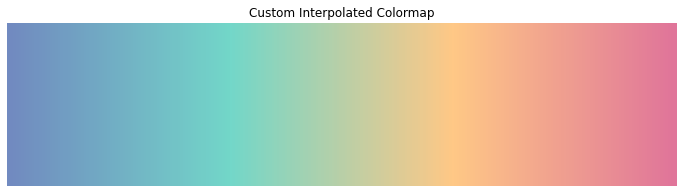

In [87]:
colors = ['#718AC0', '#73D7C9', '#FFC886', '#E0759A']

# Create interpolated colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list('custom_four_color_map', colors, N=256)
# Create gradient data
gradient = np.linspace(0, 1, 256).reshape(1, -1)

# Plot
plt.figure(figsize=(12, 3))
plt.imshow(gradient, aspect='auto', cmap=custom_cmap)
plt.axis('off')
plt.title('Custom Interpolated Colormap')
plt.show()

# Sample the colormap (returns RGBA values)
rgba = custom_cmap(np.linspace(0, 1, 256))

# Keep only RGB (drop alpha)
rgb = rgba[:, :3]

# Save as plain text
np.savetxt(
    "custom_four_color_map.txt",
    rgb,
    fmt="%.6f",
    header="R G B (values from 0 to 1)",
    comments=""
)

# 0.2wt% 20mT Sample Magnetic Data

## Full Hysteresis Curves

### Load in data for the measurements taken from 0˚–180˚ and correct diamagnetic signal

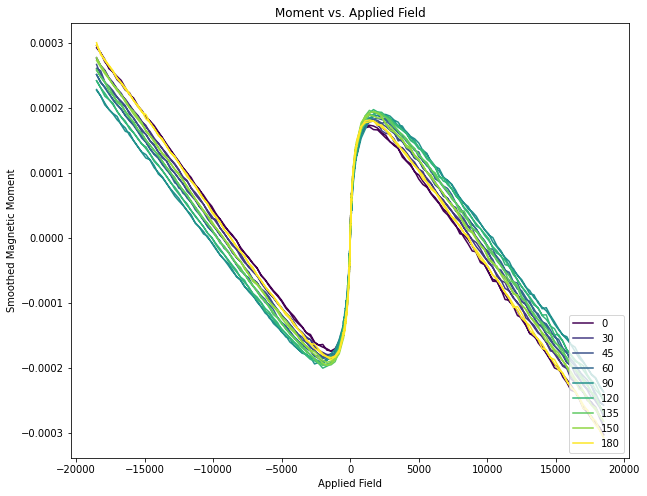

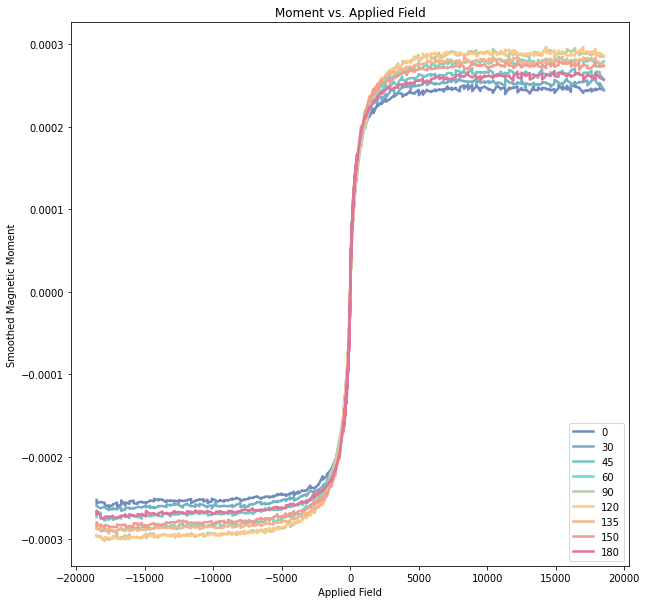

In [88]:
sample = '0.2_20mT' #Specify the sample name used to identify the directory and measurement files
angles = [0, 30, 45, 60, 90, 120, 135, 150, 180] #Define the measurement angles to be loaded and analyzed
x_data_sf, y_data_sf, _, applied_field = caf.load_x_y_data(sample, angles, str(angles[-1])) #Load the X-direction data, Y-direction data, unused processed moment data, and applied-field data for the specified sample and angles

x_data_sf = {key:x_data_sf[key] for key in angles} #Rebuild the X-direction data dictionary using only the specified measurement angles
caf.plot_hysteresis(x_data_sf, applied_field) #Plot the X-direction magnetic moment data as a function of applied magnetic field
diamag, corrected_data_sf = caf.correct_curves(x_data_sf, applied_field, 10000, plot = False) #Correct the X-direction curves for the diamagnetic contribution using a correction field value of 10000 without displaying the correction plot
sorted_arr = np.argsort(applied_field) #Determine the indices that sort the applied-field values from smallest to largest
sorted_field = applied_field[sorted_arr] #Sort the applied-field array using the calculated sorting indices
sorted_data_sf = {key: corrected_data_sf[key][sorted_arr] for key in corrected_data_sf.keys()} #Sort the corrected magnetic moment data for every measurement angle using the same applied-field ordering
caf.plot_hysteresis3(sorted_data_sf, sorted_field, lower_bound=None, upper_bound=None, cmap = custom_cmap) #Plot the sorted, diamagnetically corrected hysteresis curves using the custom colormap

### Load in data for the measurements taken from 0˚–360˚ and correct diamagnetic signals

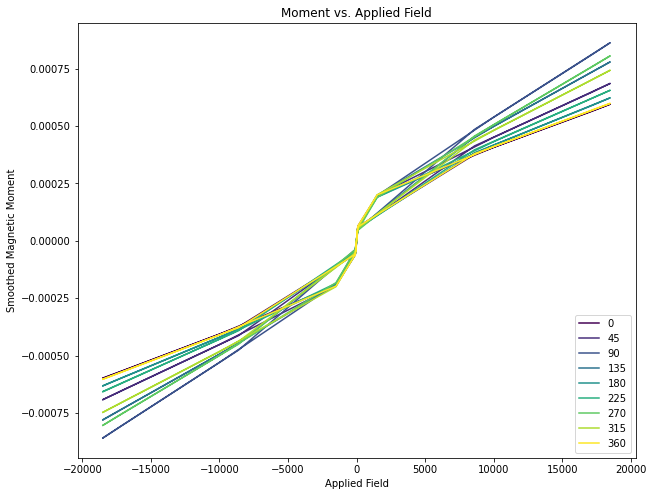

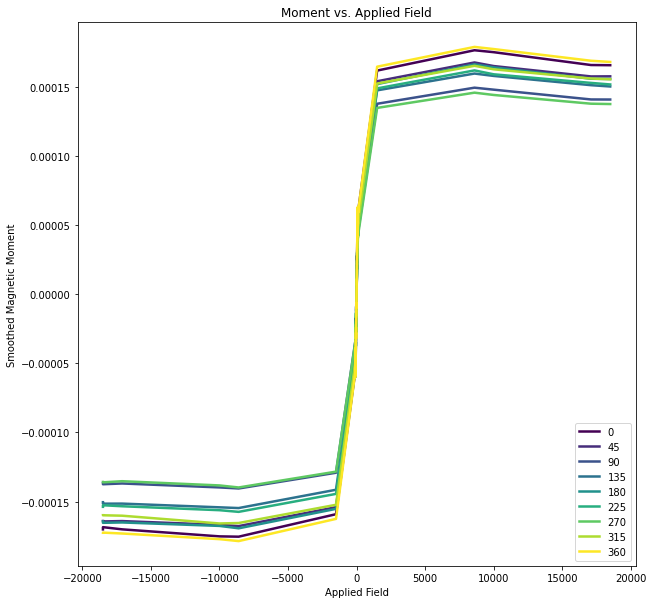

In [89]:
sample = '0.2_20mT' #Specify the sample name used to identify the directory and measurement files
angles_sf = np.linspace(0,365,74,dtype = int) #Generate an array of 74 integer measurement angles evenly spaced from 0 to 365 degrees
x_data_sf, y_data_sf, applied_field = caf.load_x_y_data360(sample, angles, '360') #Load the X-direction data, Y-direction data, and applied-field data for the specified sample from the 360-degree measurement directory

x_data_sf = {key:x_data_sf[key] for key in angles_sf} #Rebuild the X-direction data dictionary using only the measurement angles contained in angles_sf
angle_subset = [0, 45, 90, 135, 180, 225, 270, 315, 360] #Define a subset of measurement angles at 45-degree intervals for plotting
x_data_sf_subset = {key:x_data_sf[key] for key in angle_subset} #Create a dictionary containing only the X-direction data for the selected subset of angles
caf.plot_hysteresis(x_data_sf_subset, applied_field) #Plot the X-direction hysteresis curves for the selected measurement angles

diamag, corrected_data_sf = caf.correct_curves(x_data_sf, applied_field, 500, plot = False) #Correct all X-direction hysteresis curves for the diamagnetic contribution using a correction value of 500 without displaying the correction plot
sorted_arr = np.argsort(applied_field) #Determine the indices that sort the applied-field values from smallest to largest
sorted_field = applied_field[sorted_arr] #Sort the applied-field array using the calculated sorting indices
sorted_data_sf = {key: corrected_data_sf[key][sorted_arr] for key in corrected_data_sf.keys()} #Sort the corrected magnetic moment data for every measurement angle using the same applied-field ordering
sorted_data_sf_subset = {key:sorted_data_sf[key] for key in angle_subset} #Create a dictionary containing only the corrected and sorted data for the selected subset of measurement angles
caf.plot_hysteresis3(sorted_data_sf_subset, sorted_field, lower_bound=None, upper_bound=None) #Plot the corrected and sorted hysteresis curves for the selected measurement angles

### Truncate the Data to the Region of Interest
#### In this region the noise becomes more noticeable

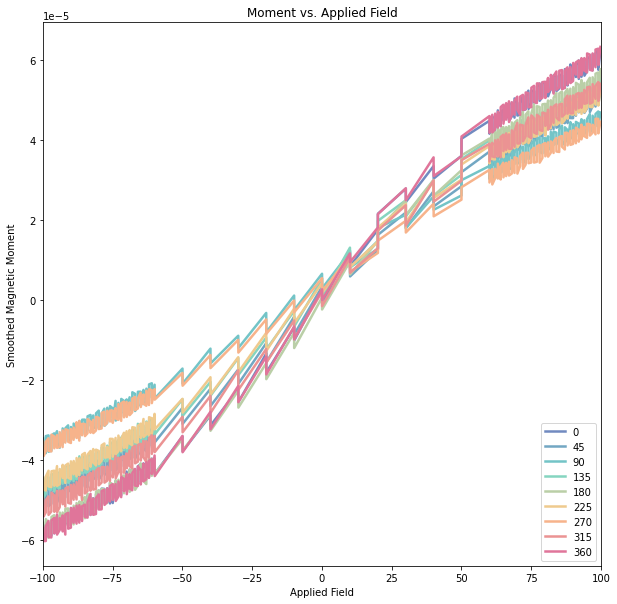

In [90]:
lower_bound = -100 #Set the lower applied-field boundary for truncating the hysteresis data
upper_bound = 100 #Set the upper applied-field boundary for truncating the hysteresis data
trunc_x, trunc_field = caf.truncate_data(sorted_data_sf,sorted_field,lower_bound = lower_bound, upper_bound= upper_bound) #Filter the corrected hysteresis data and applied-field values to retain only measurements within the specified field range

angle_subset = [0, 45, 90, 135, 180, 225, 270, 315, 360] #Define the subset of measurement angles to include in the plot
trunc_x_s = {key:trunc_x[key] for key in angle_subset} #Create a dictionary containing only the truncated X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_x_s, trunc_field, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the truncated hysteresis curves for the selected angles using the custom colormap

### Fit the data to a langevin function. Also take the error from that fitting

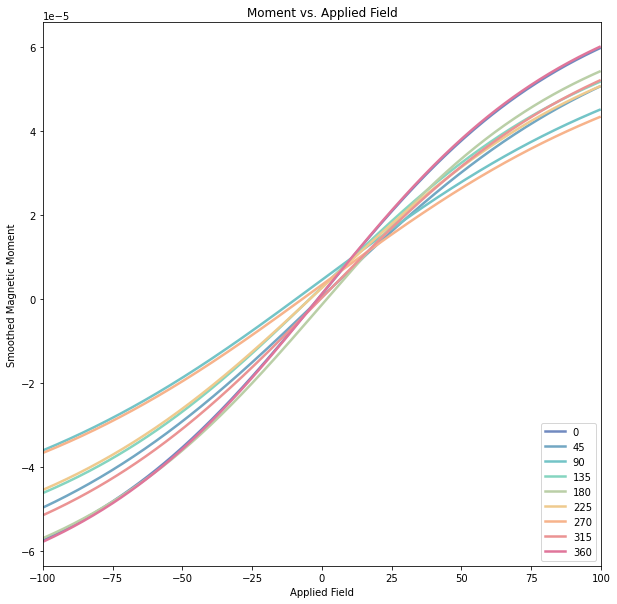

In [91]:
x_fields_sf = np.linspace(lower_bound,upper_bound,401) #Create 401 evenly spaced applied-field values between the specified lower and upper field bounds
x_params_sf, x_lang_fieldvec_sf = caf.langevin_fit_with_yerr(trunc_x, trunc_field, datapoints=x_fields_sf, sigma=1e-6, absolute_sigma=True, plot=False) #Fit the truncated X-direction data to a Langevin model at the specified field points and calculate the associated fitting uncertainties
x_small_sf = {key:x_params_sf[key]['y_fit'] for key in x_params_sf.keys()} #Extract the Langevin-fitted magnetic moment values for each measurement angle
truncated_x_lang_error_sf = {key:x_params_sf[key]['y_err'] for key in x_params_sf.keys()} #Extract the uncertainties associated with the Langevin-fitted magnetic moment values for each measurement angle

angle_subset = [0, 45, 90, 135, 180, 225, 270, 315, 360] #Define the subset of measurement angles to include in the plot
trunc_x_s = {key:x_small_sf[key] for key in angle_subset} #Create a dictionary containing only the Langevin-fitted X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_x_s, x_fields_sf, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the Langevin-fitted X-direction curves for the selected measurement angles using the custom colormap

### take a Closer Look at x and y moments near the origin

##### do all the same things with the y-data in one block

Smoothing Moments between B=-100 and B=100


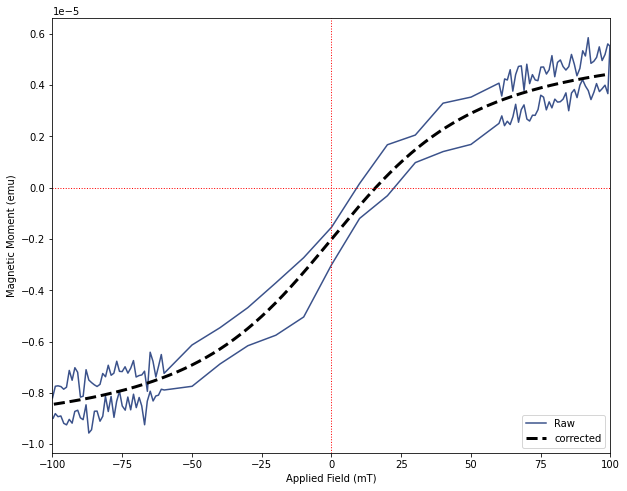

In [92]:
lower_bound = -100 #Set the lower applied-field boundary for truncating the magnetic-field data
upper_bound = 100 #Set the upper applied-field boundary for truncating the magnetic-field data
truncated_y_sf, truncated_field_sf = caf.truncate_data(y_data_sf,applied_field,lower_bound = lower_bound, upper_bound= upper_bound) #Filter the Y-direction data and applied-field values to retain only measurements within the specified field range
datapoints_sf = np.linspace(lower_bound,upper_bound,401) #Generate 401 evenly spaced applied-field values between the lower and upper field bounds for evaluating the Langevin fit
truncated_y_lang_sf, smoothed_fields_sf, truncated_y_lang_error_sf = caf.langevin_y_data360(y_data_sf, applied_field, lang_datapoints = datapoints_sf, #Apply the Langevin fitting procedure to the Y-direction data using the specified field values
                                                                           lower_transition=-100, higher_transition=100, y_error = 1e-6) #Set the low-field fitting region from -100 to 100 and specify the measurement uncertainty used for the fit
y = {key:y_data_sf[key] for key in list(y_data_sf.keys())[:9]} #Create a dictionary containing the first nine entries of the original Y-direction data
trunc_y = {key:truncated_y_lang_sf[key] for key in list(truncated_y_lang_sf.keys())[:9]} #Create a dictionary containing the first nine entries of the Langevin-fitted Y-direction data
ymagmom45 = {45: y[45]} #Create a dictionary containing the raw Y-direction magnetic moment data measured at 45 degrees
ymaglang45 = {45: trunc_y[45]} #Create a dictionary containing the Langevin-fitted Y-direction data at 45 degrees
_, _, _ = caf.plot_hysteresis_oneplot(ymagmom45, applied_field, corrected_data=ymaglang45, smoothed_field= smoothed_fields_sf, #Plot the raw and Langevin-fitted Y-direction magnetic moment data for the 45-degree measurement on the same plot
                                  lower_bound=lower_bound, upper_bound=upper_bound, set_xlim= True) #Restrict the plotted field range to the specified bounds and enable automatic x-axis limit setting

### Adjust the Hysteresis curves so that they pass through (0,0)

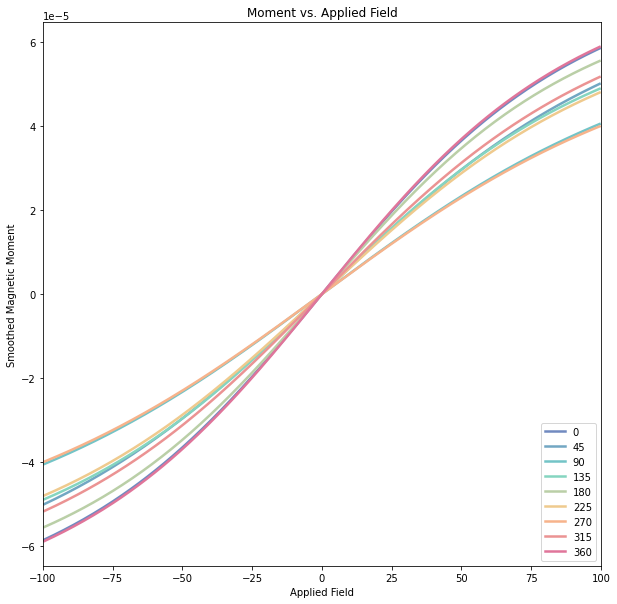

In [93]:
x_small_sf = caf.move_to_origin(x_small_sf, x_fields_sf) #Shift the fitted X-direction magnetic moment curves so that they are centered at the origin
small_field = x_fields_sf #Store the applied-field values used for the fitted curves in a separate variable
angle_subset = [0, 45, 90, 135, 180, 225, 270, 315, 360] #Define the subset of measurement angles to include in the plot
trunc_x_s = {key:x_small_sf[key] for key in angle_subset} #Create a dictionary containing only the shifted X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_x_s, x_fields_sf, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the shifted X-direction curves for the selected angles using the custom colormap and specified field limits

### Extract the X- and Y- moment values for an applied field of 10mT

X-Moment


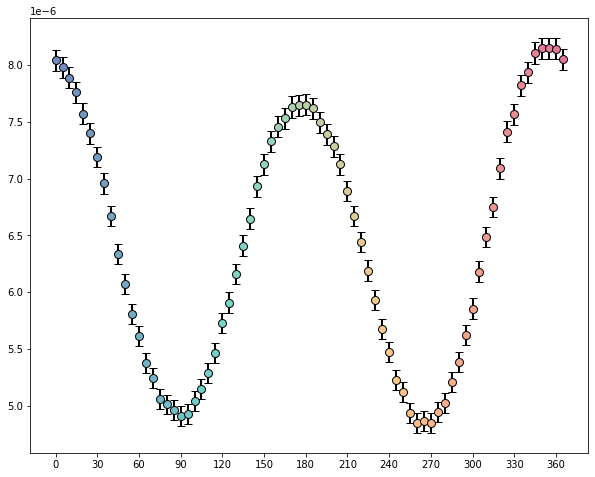

Y-Moment


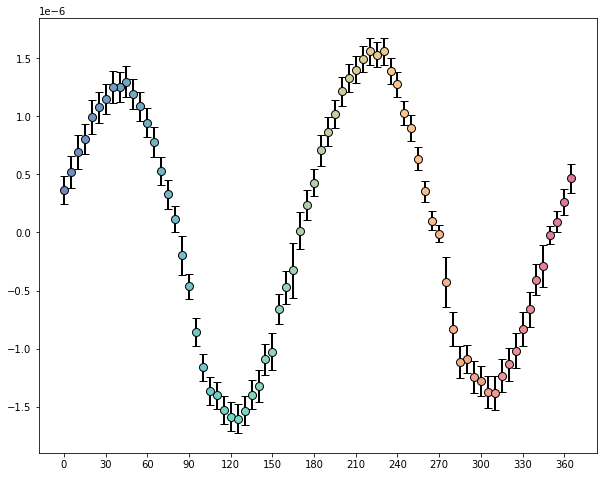

In [94]:
field = 10 #Set the applied magnetic field value at which the magnetic moment will be evaluated
mask = np.ones_like(smoothed_fields_sf, dtype=bool) #Create a boolean mask initially set to True for every smoothed-field data point
mask &= smoothed_fields_sf >= -100 #Keep only data points with applied fields greater than or equal to -100
mask &= smoothed_fields_sf <= 100 #Keep only data points with applied fields less than or equal to 100

smoothed_field_sf = x_lang_fieldvec_sf #Store the applied-field values associated with the X-direction Langevin-fitted data
x_err_sf = truncated_x_lang_error_sf #Store the uncertainties associated with the X-direction Langevin-fitted data

shifted_smoothed_y_sf = caf.move_to_origin(truncated_y_lang_sf, smoothed_fields_sf) #Shift the Y-direction Langevin-fitted curves so that their values are centered at the origin
y_small_sf = {key:shifted_smoothed_y_sf[key][mask] for key in shifted_smoothed_y_sf.keys()} #Apply the field mask to the shifted Y-direction data for every measurement angle
y_err_sf = {key:truncated_y_lang_error_sf[key][mask] for key in truncated_y_lang_error_sf.keys()} #Apply the same field mask to the Y-direction fitting uncertainties for every measurement angle

print('X-Moment') #Print a label identifying the X-direction magnetic moment analysis
moment_dict_x_sf,x_mom_err = caf.plot_specific_moment_err360(x_small_sf, smoothed_field_sf, x_err_sf, field, ylabel = "X-Moment (emu)", plot = True, cmap = custom_cmap) #Extract and plot the X-direction magnetic moment and uncertainty at the specified applied field for each measurement angle
print('Y-Moment') #Print a label identifying the Y-direction magnetic moment analysis
moment_dict_y_sf,y_mom_err = caf.plot_specific_moment_err360(y_small_sf, smoothed_field_sf, y_err_sf, field, ylabel = "Y-Moment (emu)", plot = True, cmap = custom_cmap) #Extract and plot the Y-direction magnetic moment and uncertainty at the specified applied field for each measurement angle

### Determine Magnetic Mass of the Sample

### Use the saturation values to get the approximate magnetic mass of the sample. Use the set of measurements with more datapoints

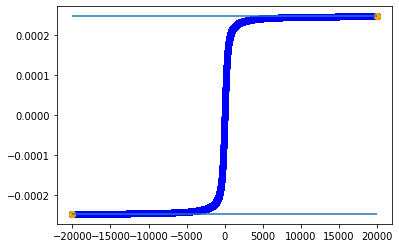

0.2 wt% Strong Field Mass:  4.296960018279996e-06


In [95]:
angles_sf = [0, 45, 90] #Define the measurement angles to load and analyze
sample = '0.2_20mT' #Specify the sample name used to identify the measurement directory and files
x_data_sf, y_data_sf, data_sf, applied_field_sf = caf.load_x_y_data(sample, angles_sf, '180') #Load the X-direction data, Y-direction data, processed moment data, and applied-field data for the selected sample and measurement angles

full_x_sf, full_field_sf = caf.truncate_data(x_data_sf,applied_field_sf,lower_bound = -20000, upper_bound= 20000) #Restrict the X-direction data and applied-field values to the range from -20000 to 20000
full_datapoints_sf = np.linspace(-20000,20000,40001) #Generate 40001 evenly spaced applied-field values between -20000 and 20000 for evaluating the Langevin fit
diamag, corrected_x_sf = caf.correct_curves(full_x_sf, full_field_sf, 5000, plot = False) #Correct the X-direction hysteresis curves for the diamagnetic contribution using a correction value of 5000 without displaying the correction plot
full_x_lang_params_sf, full_x_lang_fieldvec_sf = caf.langevin_fit_with_yerr(corrected_x_sf, full_field_sf, datapoints=full_datapoints_sf, #Fit the corrected X-direction data to a Langevin model and calculate the fitting parameters and uncertainties at the specified field values
                                                                            sigma=1e-6, absolute_sigma=True, plot=False) #Set the measurement uncertainty used for the fit and disable plotting of the Langevin fits

full_x_lang_sf = {key:full_x_lang_params_sf[key]['y_fit'] for key in full_x_lang_params_sf.keys()} #Extract the Langevin-fitted magnetic moment values for each measurement angle
full_x_lang_error_sf = {key:full_x_lang_params_sf[key]['y_err'] for key in full_x_lang_params_sf.keys()} #Extract the uncertainties associated with the Langevin-fitted magnetic moment values for each measurement angle
x = {key:x_data_sf[key] for key in list(x_data_sf.keys())} #Create a copy of the complete X-direction data dictionary
full_x = {key:full_x_lang_sf[key] for key in list(full_x_lang_sf.keys())} #Create a copy of the complete Langevin-fitted X-direction data dictionary

full_shifted_smoothed_x_sf = caf.move_to_origin(full_x_lang_sf, full_x_lang_fieldvec_sf) #Shift the Langevin-fitted X-direction curves so that their baseline is centered at the origin

x = {key:x_data_sf[key] for key in list(x_data_sf.keys())[:9]} #Create a dictionary containing the first nine entries of the original X-direction data
full_smoothed_field_sf = full_x_lang_fieldvec_sf #Store the applied-field values associated with the full Langevin-fitted X-direction data
av_satval_sf, mass_sf = caf.saturation_and_mass(full_shifted_smoothed_x_sf, plot = True, applied_field=full_x_lang_fieldvec_sf) #Calculate the average saturation magnetic moment and estimate the magnetic mass while displaying the saturation analysis plot
print('0.2 wt% Strong Field Mass: ', mass_sf) #Print the estimated magnetic mass for the 0.2 wt% sample fabricated under the strong-field condition

### Calculate Torque

/Users/collinkemper/Desktop/Paper Writing/Programmed Magnetics Paper/Code/Chain_Analysis_Functions.py:8542: RuntimeWarning: invalid value encountered in scalar divide
  dtheta_dx = -y / denom
/Users/collinkemper/Desktop/Paper Writing/Programmed Magnetics Paper/Code/Chain_Analysis_Functions.py:8543: RuntimeWarning: invalid value encountered in scalar divide
  dtheta_dy =  x / denom
/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


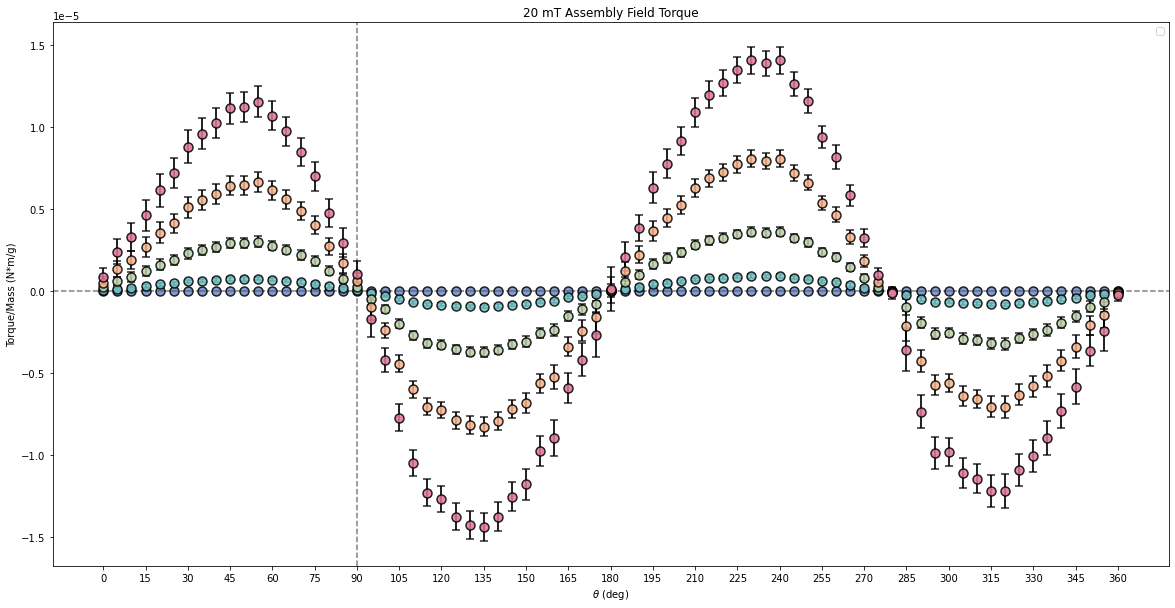

In [96]:
##Load in torque values from model
cwd = os.getcwd() #Get the current working directory
sf_model_file = os.path.join(cwd, sample, 'Strong_field_model.csv') #Construct the path to the strong-field model CSV file within the current sample directory
sf_model = pd.read_csv(sf_model_file, index_col=0, header=0) #Load the model data from the CSV file into a pandas DataFrame, using the first column as the index

fields = [0, 5, 10, 15, 20] #Define the applied magnetic field values to analyze and plot
norm = Normalize(vmin=min(fields), vmax=max(fields)) #Create a normalization object that maps the field values to the range used by the colormap
theta = np.array(([key for key in x_small_sf.keys()]))[:-1] #Create an array of measurement angles from the X-direction data keys and exclude the final angle
shift = 0 #Define an angular shift to apply to the plotted data
cmap = custom_cmap #Set the colormap used to distinguish the different applied-field values
wrap = -2 #Define the number of positions used to cyclically shift the torque data
plt.figure(figsize = (20, 10)) #Create a figure with a width of 20 inches and a height of 10 inches
plt.axvline(x=90, color="k", linestyle="--", alpha=0.5, zorder=-1) #Add a vertical reference line at 90 degrees
plt.axhline(y=0, color="k", linestyle="--", alpha=0.5, zorder=-1) #Add a horizontal reference line at zero torque
for field in fields: #Loop through each applied magnetic field value
    color = cmap(norm(field)) #Assign a colormap color based on the current applied magnetic field
    T_dict, phi_dict, T_fit, theta_fit, T_err = caf.fit_torque_to_model(x_small_sf, y_small_sf, field, smoothed_fields_sf, x_err_sf, y_err_sf,
                                                                        field_min = -100, field_max = 100, plots = False, final_plots = False) #Calculate the torque, magnetic moment angle, fitted torque, fitted angle, and torque uncertainty for the current applied field using the torque model
    T_vec = np.array([T_dict[angle] for angle in theta]) #Extract the calculated torque values for each measurement angle and store them in an ordered NumPy array
    T_vec = np.roll(T_vec, -wrap)/mass_sf #Cyclically shift the torque array and normalize the torque by the sample mass
    T_err_vec = np.array([T_err[angle] for angle in theta]) #Extract the torque uncertainties for each measurement angle and store them in an ordered NumPy array
    T_err_vec = np.roll(T_err_vec, -wrap)/mass_sf #Cyclically shift the torque uncertainty array and normalize the uncertainty by the sample mass
    if field != 0: #Only load model torque data when the applied field is nonzero
        T_sf_model = sf_model.loc[:,str(field)].to_numpy() #Extract the model torque values corresponding to the current applied field from the model DataFrame
    i = 0 #Initialize an index counter for iterating through the measurement angles
    for angle in theta: #Loop through each measurement angle
        plt.errorbar(angle+shift, T_vec[i]*-1, yerr= T_err_vec[i], fmt='o', markersize=9, markerfacecolor=color, markeredgecolor='black',
                    markeredgewidth=1.5, ecolor = 'black', elinewidth=2, capsize=4, capthick=2, alpha=0.85, zorder=2) #Plot the normalized torque at the current angle with its uncertainty as a vertical error bar
        plt.plot() #Create an empty plot command
        i += 1 #Increment the index to move to the next measurement angle

plt.legend(loc = 'best') #Display a legend using the location that best avoids overlapping the plotted data
plt.xlabel(r'$\theta$ (deg)') #Label the x-axis with the sample measurement angle in degrees
plt.ylabel('Torque/Mass (N*m/g)') #Label the y-axis with the torque normalized by sample mass
plt.title('20 mT Assembly Field Torque') #Set the plot title to describe the assembly-field condition used for the sample
plt.xticks(np.linspace(0,360,25)) #Set the x-axis tick marks to 25 evenly spaced positions between 0 and 360 degrees
plt.show() #Display the completed torque plot

### Calculate Max Torque as a function of field

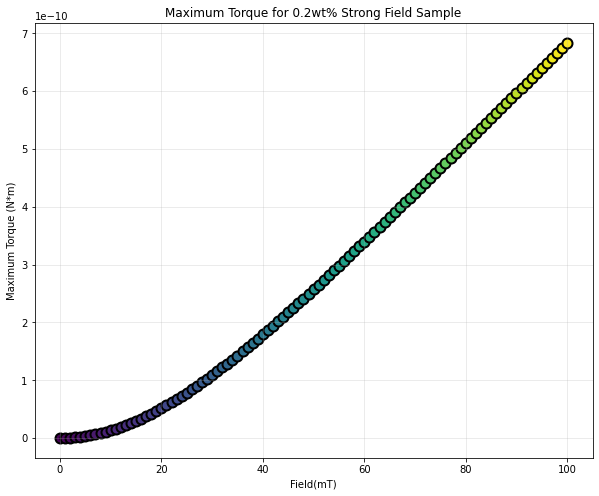

In [97]:
fields = np.linspace(0,100,101)
T_max_dict_sf = caf.plot_max_Torque(x_small_sf, y_small_sf, fields, smoothed_fields_sf, x_err_sf,
                                    y_err_sf, field_min = -100, field_max = 100, torque_plots = True, title = 'Maximum Torque for 0.2wt% Strong Field Sample')

## 0.2 wt% 0mT Sample Magnetic Data

### Full Hysteresis Curves

### Load in data for the measurements taken from 0˚–180˚ and correct diamagnetic signal

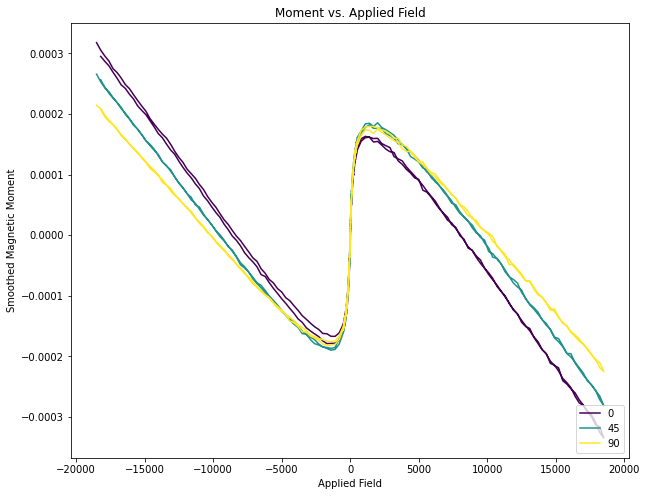

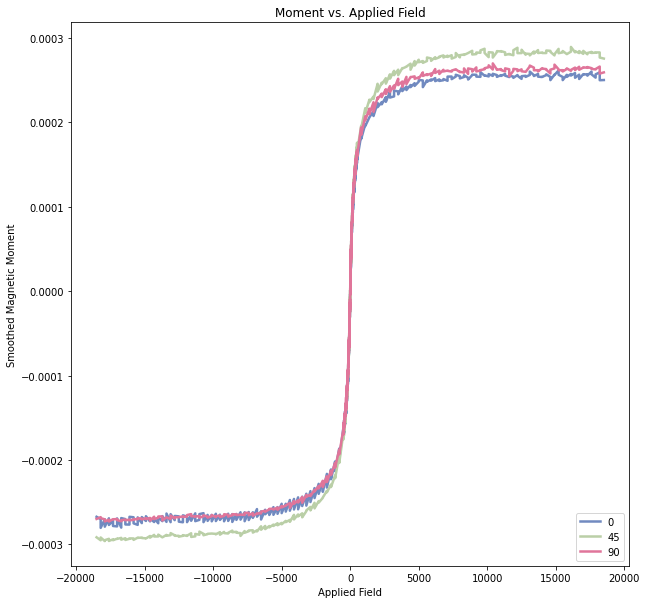

In [98]:
sample = '0.2_0mT' #Specify the sample name used to identify the directory and measurement files
angles = [0, 45, 90] #Define the measurement angles to be loaded and analyzed
x_data_nf, y_data_nf, _, applied_field = caf.load_x_y_data(sample, angles, str(angles[-1])) #Load the X-direction data, Y-direction data, unused processed moment data, and applied-field data for the specified sample and angles

x_data_nf = {key:x_data_nf[key] for key in angles} #Rebuild the X-direction data dictionary using only the specified measurement angles
caf.plot_hysteresis(x_data_nf, applied_field) #Plot the X-direction magnetic moment data as a function of applied magnetic field
diamag, corrected_data_nf = caf.correct_curves(x_data_nf, applied_field, 10000, plot = False) #Correct the X-direction curves for the diamagnetic contribution using a correction field value of 10000 without displaying the correction plot
sorted_arr = np.argsort(applied_field) #Determine the indices that sort the applied-field values from smallest to largest
sorted_field = applied_field[sorted_arr] #Sort the applied-field array using the calculated sorting indices
sorted_data_nf = {key: corrected_data_nf[key][sorted_arr] for key in corrected_data_nf.keys()} #Sort the corrected magnetic moment data for every measurement angle using the same applied-field ordering
caf.plot_hysteresis3(sorted_data_nf, sorted_field, lower_bound=None, upper_bound=None, cmap = custom_cmap) #Plot the sorted, diamagnetically corrected hysteresis curves using the custom colormap

### Load in data for the measurements taken from 0˚–360˚ and correct diamagnetic signals

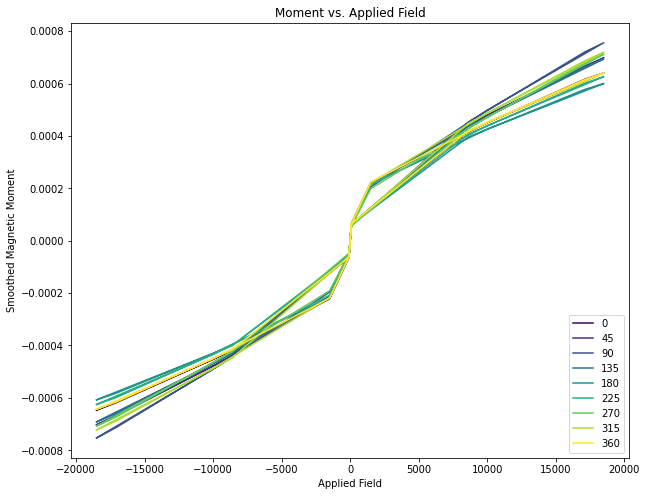

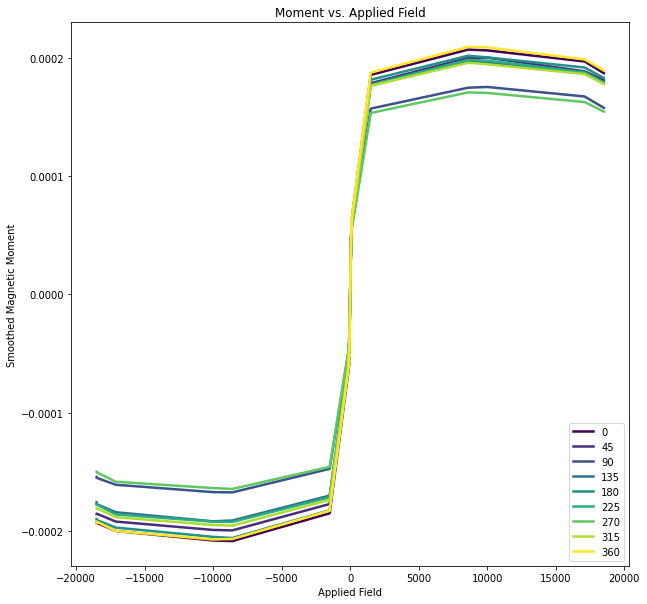

In [99]:
sample = '0.2_0mT' #Specify the sample name used to identify the directory and measurement files
angles_nf = np.linspace(0,365,74,dtype = int) #Generate an array of 74 integer measurement angles evenly spaced from 0 to 365 degrees
x_data_nf, y_data_nf, applied_field = caf.load_x_y_data360(sample, angles, '360') #Load the X-direction data, Y-direction data, and applied-field data for the specified sample from the 360-degree measurement directory

x_data_nf = {key:x_data_nf[key] for key in angles_nf} #Rebuild the X-direction data dictionary using only the measurement angles contained in angles_nf
angle_subset = [0, 45, 90, 135, 180, 225, 270, 315, 360] #Define a subset of measurement angles at 45-degree intervals for plotting
x_data_nf_subset = {key:x_data_nf[key] for key in angle_subset} #Create a dictionary containing only the X-direction data for the selected subset of angles
caf.plot_hysteresis(x_data_nf_subset, applied_field) #Plot the X-direction hysteresis curves for the selected measurement angles

diamag, corrected_data_nf = caf.correct_curves(x_data_nf, applied_field, 500, plot = False) #Correct all X-direction hysteresis curves for the diamagnetic contribution using a correction value of 500 without displaying the correction plot
sorted_arr = np.argsort(applied_field) #Determine the indices that sort the applied-field values from smallest to largest
sorted_field = applied_field[sorted_arr] #Sort the applied-field array using the calculated sorting indices
sorted_data_nf = {key: corrected_data_nf[key][sorted_arr] for key in corrected_data_nf.keys()} #Sort the corrected magnetic moment data for every measurement angle using the same applied-field ordering
sorted_data_nf_subset = {key:sorted_data_nf[key] for key in angle_subset} #Create a dictionary containing only the corrected and sorted data for the selected subset of measurement angles
caf.plot_hysteresis3(sorted_data_nf_subset, sorted_field, lower_bound=None, upper_bound=None) #Plot the corrected and sorted hysteresis curves for the selected measurement angles

### Truncate data to the region of interest

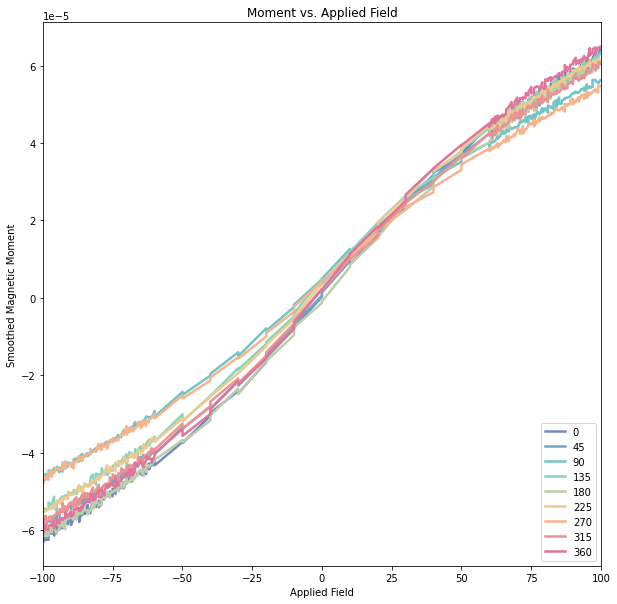

In [100]:
lower_bound = -100 #Set the lower applied-field boundary for truncating the hysteresis data
upper_bound = 100 #Set the upper applied-field boundary for truncating the hysteresis data
trunc_x, trunc_field = caf.truncate_data(sorted_data_nf,sorted_field,lower_bound = lower_bound, upper_bound= upper_bound) #Filter the corrected hysteresis data and applied-field values to retain only measurements within the specified field range

angle_subset = [0, 45, 90, 135, 180, 225, 270, 315, 360] #Define the subset of measurement angles to include in the plot
trunc_x_s = {key:trunc_x[key] for key in angle_subset} #Create a dictionary containing only the truncated X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_x_s, trunc_field, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the truncated hysteresis curves for the selected angles using the custom colormap

### Fit the data to a langevin function. Take the error from that fitting. Adjust curves to go through (0,0)

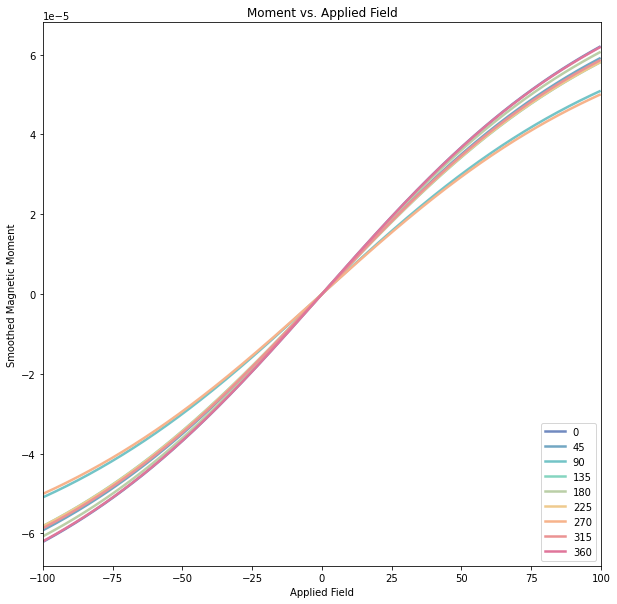

In [101]:
x_fields_nf = np.linspace(lower_bound,upper_bound,401) #Create 401 evenly spaced applied-field values between the specified lower and upper field bounds
x_params_nf, x_lang_fieldvec_nf = caf.langevin_fit_with_yerr(trunc_x, trunc_field, datapoints=x_fields_nf, sigma=1e-6, absolute_sigma=True, plot=False) #Fit the truncated X-direction data to a Langevin model at the specified field points and calculate the associated fitting uncertainties
x_small_nf = {key:x_params_nf[key]['y_fit'] for key in x_params_nf.keys()} #Extract the Langevin-fitted magnetic moment values for each measurement angle
truncated_x_lang_error_nf = {key:x_params_nf[key]['y_err'] for key in x_params_nf.keys()} #Extract the uncertainties associated with the Langevin-fitted magnetic moment values for each measurement angle
x_small_nf = caf.move_to_origin(x_small_nf, x_fields_nf) #Shift the fitted X-direction magnetic moment curves so that they are centered at the origin

angle_subset = [0, 45, 90, 135, 180, 225, 270, 315, 360] #Define the subset of measurement angles to include in the plot
trunc_x_s = {key:x_small_nf[key] for key in angle_subset} #Create a dictionary containing only the Langevin-fitted X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_x_s, x_fields_nf, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the Langevin-fitted X-direction curves for the selected measurement angles using the custom colormap

### Do all of the same with y data

Smoothing Moments between B=-100 and B=100


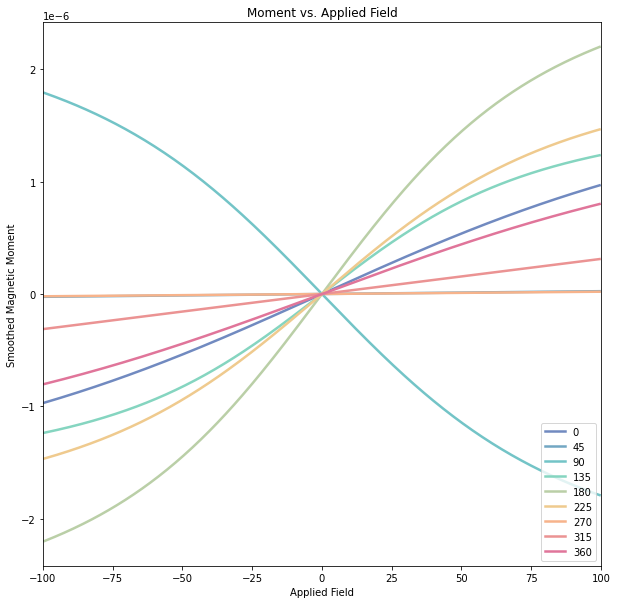

In [102]:
lower_bound = -100 #Set the lower applied-field boundary for truncating the magnetic-field data
upper_bound = 100 #Set the upper applied-field boundary for truncating the magnetic-field data
truncated_y_nf, truncated_field_nf = caf.truncate_data(y_data_nf,applied_field,lower_bound = lower_bound, upper_bound= upper_bound) #Filter the Y-direction data and applied-field values to retain only measurements within the specified field range
datapoints_nf = np.linspace(lower_bound,upper_bound,401) #Generate 401 evenly spaced applied-field values between the lower and upper field bounds for evaluating the Langevin fit
truncated_y_lang_nf, smoothed_fields_nf, truncated_y_lang_error_nf = caf.langevin_y_data360(y_data_nf, applied_field, lang_datapoints = datapoints_nf, #Apply the Langevin fitting procedure to the Y-direction data using the specified field values
                                                                           lower_transition=-100, higher_transition=100, y_error = 1e-6) #Set the low-field fitting region from -100 to 100 and specify the measurement uncertainty used for the fit
shifted_smoothed_y_nf = caf.move_to_origin(truncated_y_lang_nf, smoothed_fields_nf) #Shift the Y-direction Langevin-fitted curves so that their values are centered at the origin
angle_subset = [0, 45, 90, 135, 180, 225, 270, 315, 360] #Define the subset of measurement angles to include in the plot
trunc_y_s = {key:shifted_smoothed_y_nf[key] for key in angle_subset} #Create a dictionary containing only the Langevin-fitted X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_y_s, smoothed_fields_nf, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the Langevin-fitted X-direction curves for the selected measurement angles using the custom colormap

### Extract the X- and Y- moment values for an applied field of 10mT

X-Moment


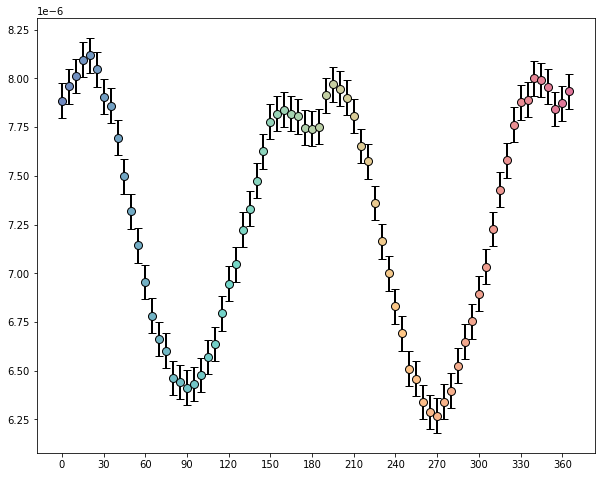

Y-Moment


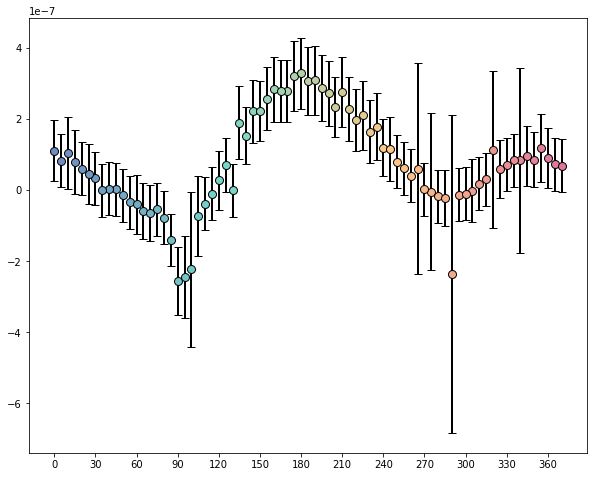

In [103]:
field = 10 #Set the applied magnetic field value at which the magnetic moment will be evaluated
mask = np.ones_like(smoothed_fields_nf, dtype=bool) #Create a boolean mask initially set to True for every smoothed-field data point
mask &= smoothed_fields_nf >= -100 #Keep only data points with applied fields greater than or equal to -100
mask &= smoothed_fields_nf <= 100 #Keep only data points with applied fields less than or equal to 100

smoothed_field_nf = x_lang_fieldvec_nf #Store the applied-field values associated with the X-direction Langevin-fitted data
x_err_nf = truncated_x_lang_error_nf #Store the uncertainties associated with the X-direction Langevin-fitted data

shifted_smoothed_y_nf = caf.move_to_origin(truncated_y_lang_nf, smoothed_fields_nf) #Shift the Y-direction Langevin-fitted curves so that their values are centered at the origin
y_small_nf = {key:shifted_smoothed_y_nf[key][mask] for key in shifted_smoothed_y_nf.keys()} #Apply the field mask to the shifted Y-direction data for every measurement angle
y_err_nf = {key:truncated_y_lang_error_nf[key][mask] for key in truncated_y_lang_error_nf.keys()} #Apply the same field mask to the Y-direction fitting uncertainties for every measurement angle

print('X-Moment') #Print a label identifying the X-direction magnetic moment analysis
moment_dict_x_nf,x_mom_err = caf.plot_specific_moment_err360(x_small_nf, smoothed_field_nf, x_err_nf, field, ylabel = "X-Moment (emu)", plot = True, cmap = custom_cmap) #Extract and plot the X-direction magnetic moment and uncertainty at the specified applied field for each measurement angle
print('Y-Moment') #Print a label identifying the Y-direction magnetic moment analysis
moment_dict_y_nf,y_mom_err = caf.plot_specific_moment_err360(y_small_nf, smoothed_field_nf, y_err_nf, field, ylabel = "Y-Moment (emu)", plot = True, cmap = custom_cmap) #Extract and plot the Y-direction magnetic moment and uncertainty at the specified applied field for each measurement angle

### Determine magnetic mass of the sample

### Use the saturation values to get the approximate magnetic mass of the sample. Use the set of measurements with more datapoints

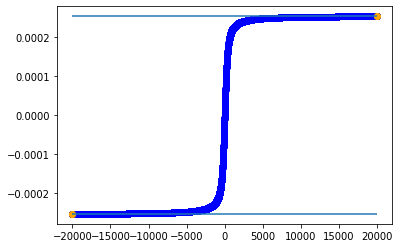

0.2 wt% No Field Mass:  4.156313598224653e-06


In [104]:
angles_nf = [0, 45, 90] #Define the measurement angles to load and analyze
sample = '0.2_0mT' #Specify the sample name used to identify the measurement directory and files
x_data_nf, y_data_nf, data_nf, applied_field_nf = caf.load_x_y_data(sample, angles_nf, '90') #Load the X-direction data, Y-direction data, processed moment data, and applied-field data for the selected sample and measurement angles

full_x_nf, full_field_nf = caf.truncate_data(x_data_nf,applied_field_nf,lower_bound = -20000, upper_bound= 20000) #Restrict the X-direction data and applied-field values to the range from -20000 to 20000
full_datapoints_nf = np.linspace(-20000,20000,40001) #Generate 40001 evenly spaced applied-field values between -20000 and 20000 for evaluating the Langevin fit
diamag, corrected_x_nf = caf.correct_curves(full_x_nf, full_field_nf, 5000, plot = False) #Correct the X-direction hysteresis curves for the diamagnetic contribution using a correction value of 5000 without displaying the correction plot
full_x_lang_params_nf, full_x_lang_fieldvec_nf = caf.langevin_fit_with_yerr(corrected_x_nf, full_field_nf, datapoints=full_datapoints_nf, #Fit the corrected X-direction data to a Langevin model and calculate the fitting parameters and uncertainties at the specified field values
                                                                            sigma=1e-6, absolute_sigma=True, plot=False) #Set the measurement uncertainty used for the fit and disable plotting of the Langevin fits

full_x_lang_nf = {key:full_x_lang_params_nf[key]['y_fit'] for key in full_x_lang_params_nf.keys()} #Extract the Langevin-fitted magnetic moment values for each measurement angle
full_x_lang_error_nf = {key:full_x_lang_params_nf[key]['y_err'] for key in full_x_lang_params_nf.keys()} #Extract the uncertainties associated with the Langevin-fitted magnetic moment values for each measurement angle
x = {key:x_data_nf[key] for key in list(x_data_nf.keys())} #Create a copy of the complete X-direction data dictionary
full_x = {key:full_x_lang_nf[key] for key in list(full_x_lang_nf.keys())} #Create a copy of the complete Langevin-fitted X-direction data dictionary

full_shifted_smoothed_x_nf = caf.move_to_origin(full_x_lang_nf, full_x_lang_fieldvec_nf) #Shift the Langevin-fitted X-direction curves so that their baseline is centered at the origin

x = {key:x_data_nf[key] for key in list(x_data_nf.keys())[:9]} #Create a dictionary containing the first nine entries of the original X-direction data
full_smoothed_field_nf = full_x_lang_fieldvec_nf #Store the applied-field values associated with the full Langevin-fitted X-direction data
av_satval_nf, mass_nf = caf.saturation_and_mass(full_shifted_smoothed_x_nf, plot = True, applied_field=full_x_lang_fieldvec_nf) #Calculate the average saturation magnetic moment and estimate the magnetic mass while displaying the saturation analysis plot
print('0.2 wt% No Field Mass: ', mass_nf) #Print the estimated magnetic mass for the 0.2 wt% sample fabricated under the strong-field condition

### Calculate Torque

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


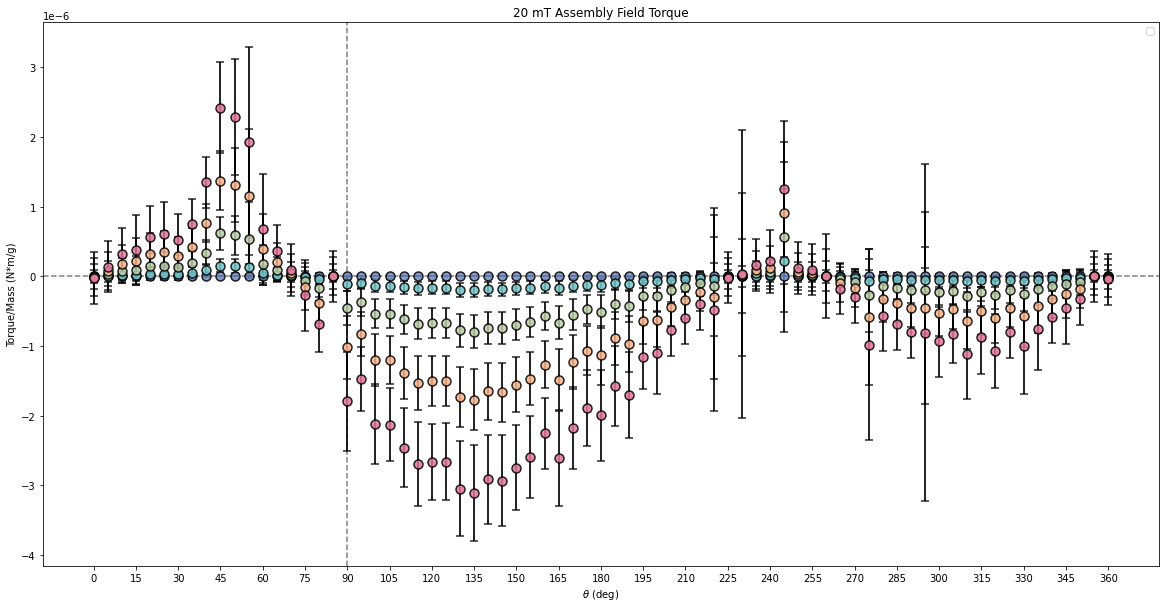

In [105]:
sample = '0.2_0mT' #Specify the sample name used to identify the directory and measurement files
cwd = os.getcwd() #Get the current working directory
nf_model_file = os.path.join(cwd, sample, 'No_field_model.csv') #Construct the path to the strong-field model CSV file within the current sample directory
nf_model = pd.read_csv(nf_model_file, index_col=0, header=0) #Load the model data from the CSV file into a pandas DataFrame, using the first column as the index

fields = [0, 5, 10, 15, 20] #Define the applied magnetic field values to analyze and plot
norm = Normalize(vmin=min(fields), vmax=max(fields)) #Create a normalization object that maps the field values to the range used by the colormap
theta = np.array(([key for key in x_small_nf.keys()]))[:-1] #Create an array of measurement angles from the X-direction data keys and exclude the final angle
shift = 0 #Define an angular shift to apply to the plotted data
cmap = custom_cmap #Set the colormap used to distinguish the different applied-field values
wrap = 9 #Define the number of positions used to cyclically shift the torque data
plt.figure(figsize = (20, 10)) #Create a figure with a width of 20 inches and a height of 10 inches
plt.axvline(x=90, color="k", linestyle="--", alpha=0.5, zorder=-1) #Add a vertical reference line at 90 degrees
plt.axhline(y=0, color="k", linestyle="--", alpha=0.5, zorder=-1) #Add a horizontal reference line at zero torque
for field in fields: #Loop through each applied magnetic field value
    color = cmap(norm(field)) #Assign a colormap color based on the current applied magnetic field
    T_dict, phi_dict, T_fit, theta_fit, T_err = caf.fit_torque_to_model(x_small_nf, y_small_nf, field, smoothed_fields_nf, x_err_nf, y_err_nf,
                                                                        field_min = -100, field_max = 100, plots = False, final_plots = False) #Calculate the torque, magnetic moment angle, fitted torque, fitted angle, and torque uncertainty for the current applied field using the torque model
    T_vec = np.array([T_dict[angle] for angle in theta]) #Extract the calculated torque values for each measurement angle and store them in an ordered NumPy array
    T_vec = np.roll(T_vec, -wrap)/mass_nf #Cyclically shift the torque array and normalize the torque by the sample mass
    T_err_vec = np.array([T_err[angle] for angle in theta]) #Extract the torque uncertainties for each measurement angle and store them in an ordered NumPy array
    T_err_vec = np.roll(T_err_vec, -wrap)/mass_nf #Cyclically shift the torque uncertainty array and normalize the uncertainty by the sample mass
    if field != 0: #Only load model torque data when the applied field is nonzero
        T_nf_model = nf_model.loc[:,str(field)].to_numpy() #Extract the model torque values corresponding to the current applied field from the model DataFrame
    i = 0 #Initialize an index counter for iterating through the measurement angles
    for angle in theta: #Loop through each measurement angle
        plt.errorbar(angle+shift, T_vec[i], yerr= T_err_vec[i], fmt='o', markersize=9, markerfacecolor=color, markeredgecolor='black',
                    markeredgewidth=1.5, ecolor = 'black', elinewidth=2, capsize=4, capthick=2, alpha=0.85, zorder=2) #Plot the normalized torque at the current angle with its uncertainty as a vertical error bar
        plt.plot() #Create an empty plot command
        i += 1 #Increment the index to move to the next measurement angle

plt.legend(loc = 'best') #Display a legend using the location that best avoids overlapping the plotted data
plt.xlabel(r'$\theta$ (deg)') #Label the x-axis with the sample measurement angle in degrees
plt.ylabel('Torque/Mass (N*m/g)') #Label the y-axis with the torque normalized by sample mass
plt.title('20 mT Assembly Field Torque') #Set the plot title to describe the assembly-field condition used for the sample
plt.xticks(np.linspace(0,360,25)) #Set the x-axis tick marks to 25 evenly spaced positions between 0 and 360 degrees
plt.show() #Display the completed torque plot

### Calculate Max Torque as a Function of Field

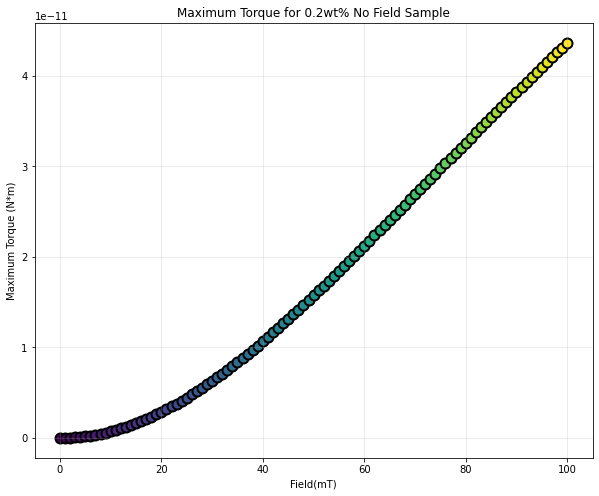

In [106]:
fields = np.linspace(0,100,101)
T_max_dict_nf = caf.plot_max_Torque(x_small_nf, y_small_nf, fields, smoothed_fields_nf, x_err_nf,
                                    y_err_nf, field_min = -100, field_max = 100, torque_plots = True, title = 'Maximum Torque for 0.2wt% No Field Sample')

## 0.2. wt% 4mT Sample Magnetometry Data

### Load in data for the measurements taken from 0˚–180˚ and correct diamagnetic signal

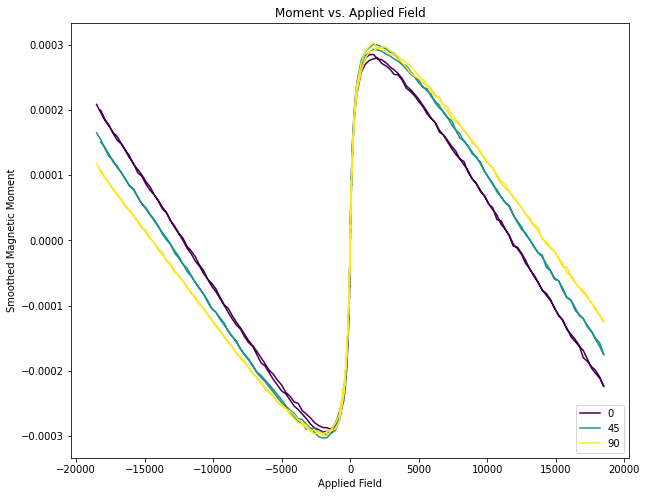

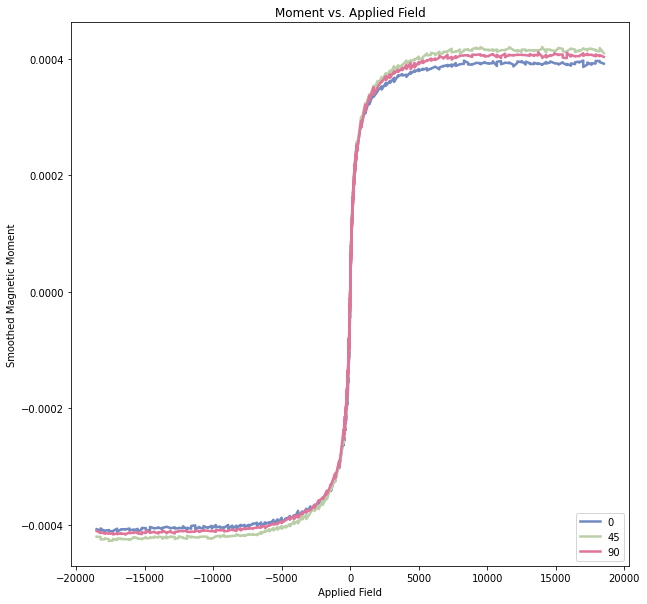

In [107]:
sample = '0.2_4mT' #Specify the sample name used to identify the directory and measurement files
angles = [0, 45, 90] #Define the measurement angles to be loaded and analyzed
x_data_wf, y_data_wf, _, applied_field = caf.load_x_y_data(sample, angles, str(angles[-1])) #Load the X-direction data, Y-direction data, unused processed moment data, and applied-field data for the specified sample and angles

x_data_wf = {key:x_data_wf[key] for key in angles} #Rebuild the X-direction data dictionary using only the specified measurement angles
caf.plot_hysteresis(x_data_wf, applied_field) #Plot the X-direction magnetic moment data as a function of applied magnetic field
diamag, corrected_data_wf = caf.correct_curves(x_data_wf, applied_field, 10000, plot = False) #Correct the X-direction curves for the diamagnetic contribution using a correction field value of 10000 without displaying the correction plot
sorted_arr = np.argsort(applied_field) #Determine the indices that sort the applied-field values from smallest to largest
sorted_field = applied_field[sorted_arr] #Sort the applied-field array using the calculated sorting indices
sorted_data_wf = {key: corrected_data_wf[key][sorted_arr] for key in corrected_data_wf.keys()} #Sort the corrected magnetic moment data for every measurement angle using the same applied-field ordering
caf.plot_hysteresis3(sorted_data_wf, sorted_field, lower_bound=None, upper_bound=None, cmap = custom_cmap) #Plot the sorted, diamagnetically corrected hysteresis curves using the custom colormap

### Load in data for the measurements taken from 0˚–360˚ and correct diamagnetic signals

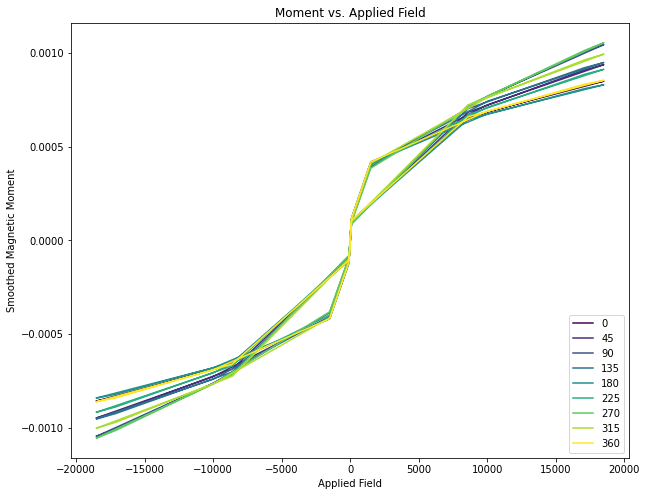

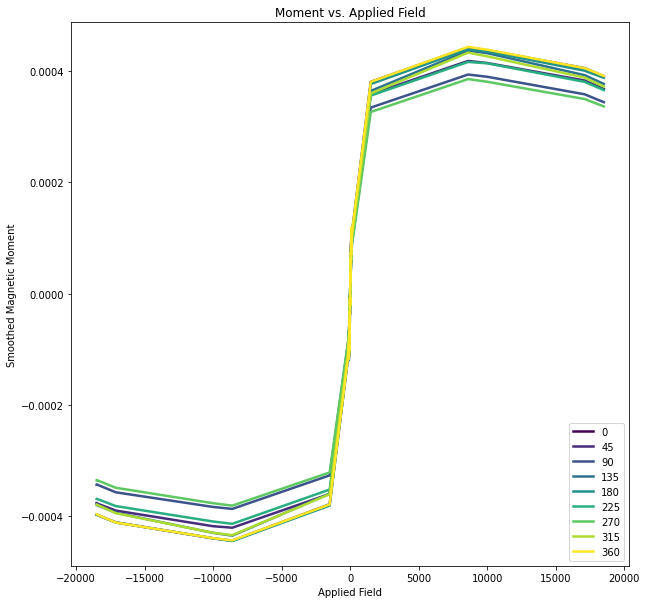

In [108]:
sample = '0.2_4mT' #Specify the sample name used to identify the directory and measurement files
angles_wf = np.linspace(0,365,74,dtype = int) #Generate an array of 74 integer measurement angles evenly spaced from 0 to 365 degrees
x_data_wf, y_data_wf, applied_field = caf.load_x_y_data360(sample, angles, '360') #Load the X-direction data, Y-direction data, and applied-field data for the specified sample from the 360-degree measurement directory

x_data_wf = {key:x_data_wf[key] for key in angles_wf} #Rebuild the X-direction data dictionary using only the measurement angles contained in angles_wf
angle_subset = [0, 45, 90, 135, 180, 225, 270, 315, 360] #Define a subset of measurement angles at 45-degree intervals for plotting
x_data_wf_subset = {key:x_data_wf[key] for key in angle_subset} #Create a dictionary containing only the X-direction data for the selected subset of angles
caf.plot_hysteresis(x_data_wf_subset, applied_field) #Plot the X-direction hysteresis curves for the selected measurement angles

diamag, corrected_data_wf = caf.correct_curves(x_data_wf, applied_field, 500, plot = False) #Correct all X-direction hysteresis curves for the diamagnetic contribution using a correction value of 500 without displaying the correction plot
sorted_arr = np.argsort(applied_field) #Determine the indices that sort the applied-field values from smallest to largest
sorted_field = applied_field[sorted_arr] #Sort the applied-field array using the calculated sorting indices
sorted_data_wf = {key: corrected_data_wf[key][sorted_arr] for key in corrected_data_wf.keys()} #Sort the corrected magnetic moment data for every measurement angle using the same applied-field ordering
sorted_data_wf_subset = {key:sorted_data_wf[key] for key in angle_subset} #Create a dictionary containing only the corrected and sorted data for the selected subset of measurement angles
caf.plot_hysteresis3(sorted_data_wf_subset, sorted_field, lower_bound=None, upper_bound=None) #Plot the corrected and sorted hysteresis curves for the selected measurement angles

### Truncate Data to region ofinterest

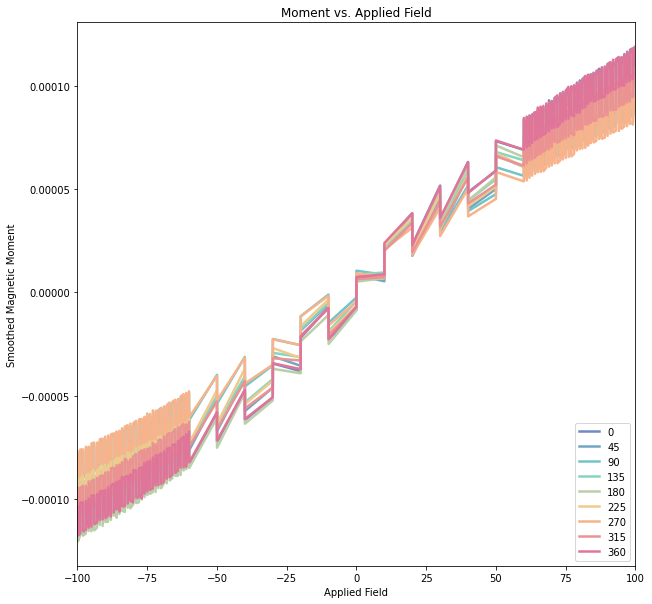

In [109]:
lower_bound = -100 #Set the lower applied-field boundary for truncating the hysteresis data
upper_bound = 100 #Set the upper applied-field boundary for truncating the hysteresis data
trunc_x, trunc_field = caf.truncate_data(sorted_data_wf,sorted_field,lower_bound = lower_bound, upper_bound= upper_bound) #Filter the corrected hysteresis data and applied-field values to retain only measurements within the specified field range

angle_subset = [0, 45, 90, 135, 180, 225, 270, 315, 360] #Define the subset of measurement angles to include in the plot
trunc_x_s = {key:trunc_x[key] for key in angle_subset} #Create a dictionary containing only the truncated X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_x_s, trunc_field, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the truncated hysteresis curves for the selected angles using the custom colormap

### Fit the data to a langevin function. Take the error from that fitting. Adjust curves to go through (0,0)

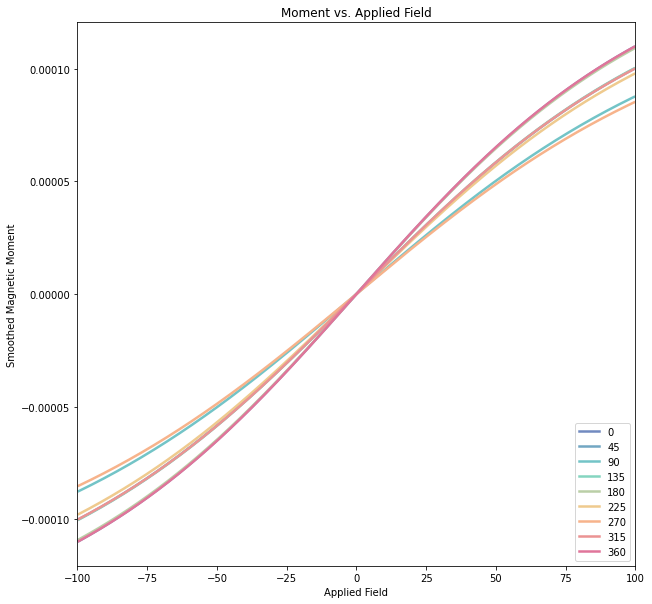

In [110]:
x_fields_wf = np.linspace(lower_bound,upper_bound,401) #Create 401 evenly spaced applied-field values between the specified lower and upper field bounds
x_params_wf, x_lang_fieldvec_wf = caf.langevin_fit_with_yerr(trunc_x, trunc_field, datapoints=x_fields_wf, sigma=1e-6, absolute_sigma=True, plot=False) #Fit the truncated X-direction data to a Langevin model at the specified field points and calculate the associated fitting uncertainties
x_small_wf = {key:x_params_wf[key]['y_fit'] for key in x_params_wf.keys()} #Extract the Langevin-fitted magnetic moment values for each measurement angle
truncated_x_lang_error_wf = {key:x_params_wf[key]['y_err'] for key in x_params_wf.keys()} #Extract the uncertainties associated with the Langevin-fitted magnetic moment values for each measurement angle
x_small_wf = caf.move_to_origin(x_small_wf, x_fields_wf) #Shift the fitted X-direction magnetic moment curves so that they are centered at the origin

angle_subset = [0, 45, 90, 135, 180, 225, 270, 315, 360] #Define the subset of measurement angles to include in the plot
trunc_x_s = {key:x_small_wf[key] for key in angle_subset} #Create a dictionary containing only the Langevin-fitted X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_x_s, x_fields_wf, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the Langevin-fitted X-direction curves for the selected measurement angles using the custom colormap

### Do all the same with y-data

Smoothing Moments between B=-100 and B=100


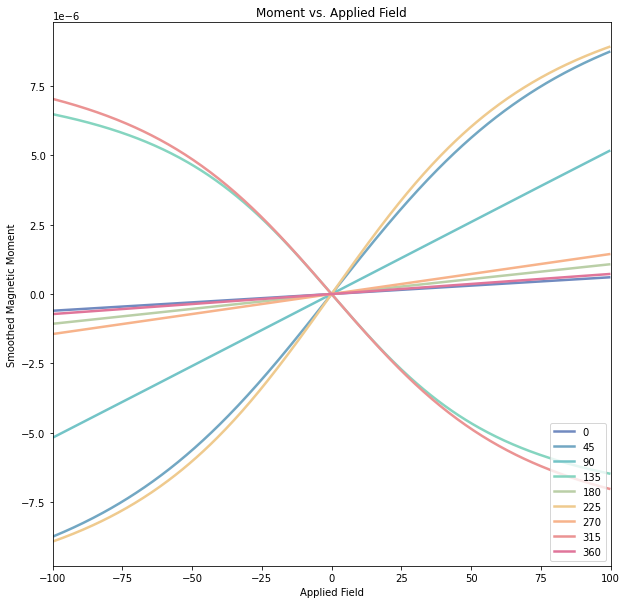

In [111]:
lower_bound = -100 #Set the lower applied-field boundary for truncating the magnetic-field data
upper_bound = 100 #Set the upper applied-field boundary for truncating the magnetic-field data
truncated_y_wf, truncated_field_wf = caf.truncate_data(y_data_wf,applied_field,lower_bound = lower_bound, upper_bound= upper_bound) #Filter the Y-direction data and applied-field values to retain only measurements within the specified field range
datapoints_wf = np.linspace(lower_bound,upper_bound,401) #Generate 401 evenly spaced applied-field values between the lower and upper field bounds for evaluating the Langevin fit
truncated_y_lang_wf, smoothed_fields_wf, truncated_y_lang_error_wf = caf.langevin_y_data360(y_data_wf, applied_field, lang_datapoints = datapoints_wf, #Apply the Langevin fitting procedure to the Y-direction data using the specified field values
                                                                           lower_transition=-100, higher_transition=100, y_error = 1e-6) #Set the low-field fitting region from -100 to 100 and specify the measurement uncertainty used for the fit
shifted_smoothed_y_wf = caf.move_to_origin(truncated_y_lang_wf, smoothed_fields_wf) #Shift the Y-direction Langevin-fitted curves so that their values are centered at the origin
angle_subset = [0, 45, 90, 135, 180, 225, 270, 315, 360] #Define the subset of measurement angles to include in the plot
trunc_y_s = {key:shifted_smoothed_y_wf[key] for key in angle_subset} #Create a dictionary containing only the Langevin-fitted X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_y_s, smoothed_fields_wf, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the Langevin-fitted X-direction curves for the selected measurement angles using the custom colormap

### Extract the X- and Y- moment values for an applied field of 10mT

X-Moment


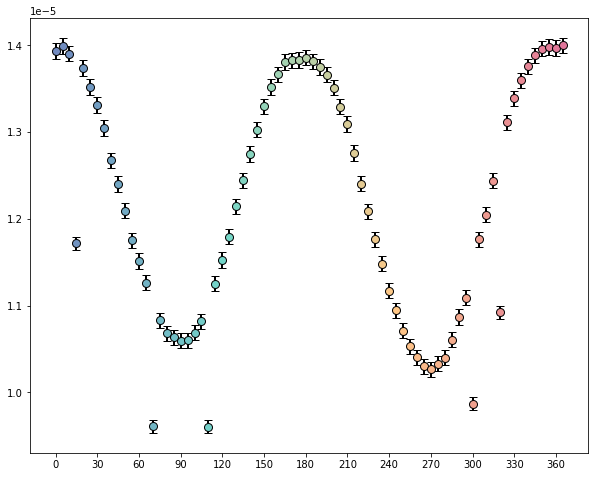

Y-Moment


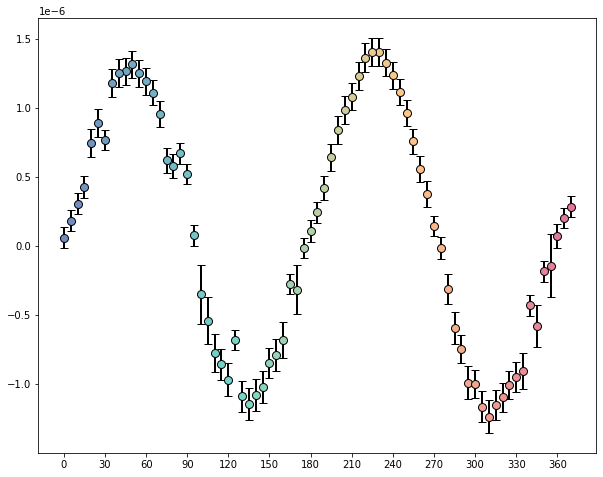

In [112]:
field = 10 #Set the applied magnetic field value at which the magnetic moment will be evaluated
mask = np.ones_like(smoothed_fields_wf, dtype=bool) #Create a boolean mask initially set to True for every smoothed-field data point
mask &= smoothed_fields_wf >= -100 #Keep only data points with applied fields greater than or equal to -100
mask &= smoothed_fields_wf <= 100 #Keep only data points with applied fields less than or equal to 100

smoothed_field_wf = x_lang_fieldvec_wf #Store the applied-field values associated with the X-direction Langevin-fitted data
x_err_wf = truncated_x_lang_error_wf #Store the uncertainties associated with the X-direction Langevin-fitted data

shifted_smoothed_y_wf = caf.move_to_origin(truncated_y_lang_wf, smoothed_fields_wf) #Shift the Y-direction Langevin-fitted curves so that their values are centered at the origin
y_small_wf = {key:shifted_smoothed_y_wf[key][mask] for key in shifted_smoothed_y_wf.keys()} #Apply the field mask to the shifted Y-direction data for every measurement angle
y_err_wf = {key:truncated_y_lang_error_wf[key][mask] for key in truncated_y_lang_error_wf.keys()} #Apply the same field mask to the Y-direction fitting uncertainties for every measurement angle

print('X-Moment') #Print a label identifying the X-direction magnetic moment analysis
moment_dict_x_wf,x_mom_err = caf.plot_specific_moment_err360(x_small_wf, smoothed_field_wf, x_err_wf, field, ylabel = "X-Moment (emu)", plot = True, cmap = custom_cmap) #Extract and plot the X-direction magnetic moment and uncertainty at the specified applied field for each measurement angle
print('Y-Moment') #Print a label identifying the Y-direction magnetic moment analysis
moment_dict_y_wf,y_mom_err = caf.plot_specific_moment_err360(y_small_wf, smoothed_field_wf, y_err_wf, field, ylabel = "Y-Moment (emu)", plot = True, cmap = custom_cmap) #Extract and plot the Y-direction magnetic moment and uncertainty at the specified applied field for each measurement angle

### Determine the magentic mass of the sample

### Use the saturation values to get the approximate magnetic mass of the sample. Use the set of measurements with more datapoints

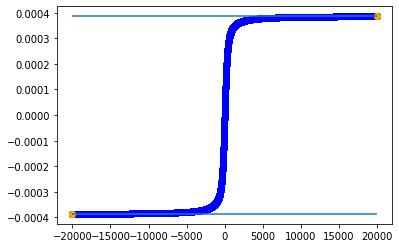

0.2 wt% No Field Mass:  6.303924764313696e-06


In [113]:
angles_wf = [0, 45, 90] #Define the measurement angles to load and analyze
sample = '0.2_4mT' #Specify the sample name used to identify the measurement directory and files
x_data_wf, y_data_wf, data_wf, applied_field_wf = caf.load_x_y_data(sample, angles_wf, '90') #Load the X-direction data, Y-direction data, processed moment data, and applied-field data for the selected sample and measurement angles

full_x_wf, full_field_wf = caf.truncate_data(x_data_wf,applied_field_wf,lower_bound = -20000, upper_bound= 20000) #Restrict the X-direction data and applied-field values to the range from -20000 to 20000
full_datapoints_wf = np.linspace(-20000,20000,40001) #Generate 40001 evenly spaced applied-field values between -20000 and 20000 for evaluating the Langevin fit
diamag, corrected_x_wf = caf.correct_curves(full_x_wf, full_field_wf, 5000, plot = False) #Correct the X-direction hysteresis curves for the diamagnetic contribution using a correction value of 5000 without displaying the correction plot
full_x_lang_params_wf, full_x_lang_fieldvec_wf = caf.langevin_fit_with_yerr(corrected_x_wf, full_field_wf, datapoints=full_datapoints_wf, #Fit the corrected X-direction data to a Langevin model and calculate the fitting parameters and uncertainties at the specified field values
                                                                            sigma=1e-6, absolute_sigma=True, plot=False) #Set the measurement uncertainty used for the fit and disable plotting of the Langevin fits

full_x_lang_wf = {key:full_x_lang_params_wf[key]['y_fit'] for key in full_x_lang_params_wf.keys()} #Extract the Langevin-fitted magnetic moment values for each measurement angle
full_x_lang_error_wf = {key:full_x_lang_params_wf[key]['y_err'] for key in full_x_lang_params_wf.keys()} #Extract the uncertainties associated with the Langevin-fitted magnetic moment values for each measurement angle
x = {key:x_data_wf[key] for key in list(x_data_wf.keys())} #Create a copy of the complete X-direction data dictionary
full_x = {key:full_x_lang_wf[key] for key in list(full_x_lang_wf.keys())} #Create a copy of the complete Langevin-fitted X-direction data dictionary

full_shifted_smoothed_x_wf = caf.move_to_origin(full_x_lang_wf, full_x_lang_fieldvec_wf) #Shift the Langevin-fitted X-direction curves so that their baseline is centered at the origin

x = {key:x_data_wf[key] for key in list(x_data_wf.keys())[:9]} #Create a dictionary containing the first nine entries of the original X-direction data
full_smoothed_field_wf = full_x_lang_fieldvec_wf #Store the applied-field values associated with the full Langevin-fitted X-direction data
av_satval_wf, mass_wf = caf.saturation_and_mass(full_shifted_smoothed_x_wf, plot = True, applied_field=full_x_lang_fieldvec_wf) #Calculate the average saturation magnetic moment and estimate the magnetic mass while displaying the saturation analysis plot
print('0.2 wt% No Field Mass: ', mass_wf) #Print the estimated magnetic mass for the 0.2 wt% sample fabricated under the strong-field condition

### Calculate Torque

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


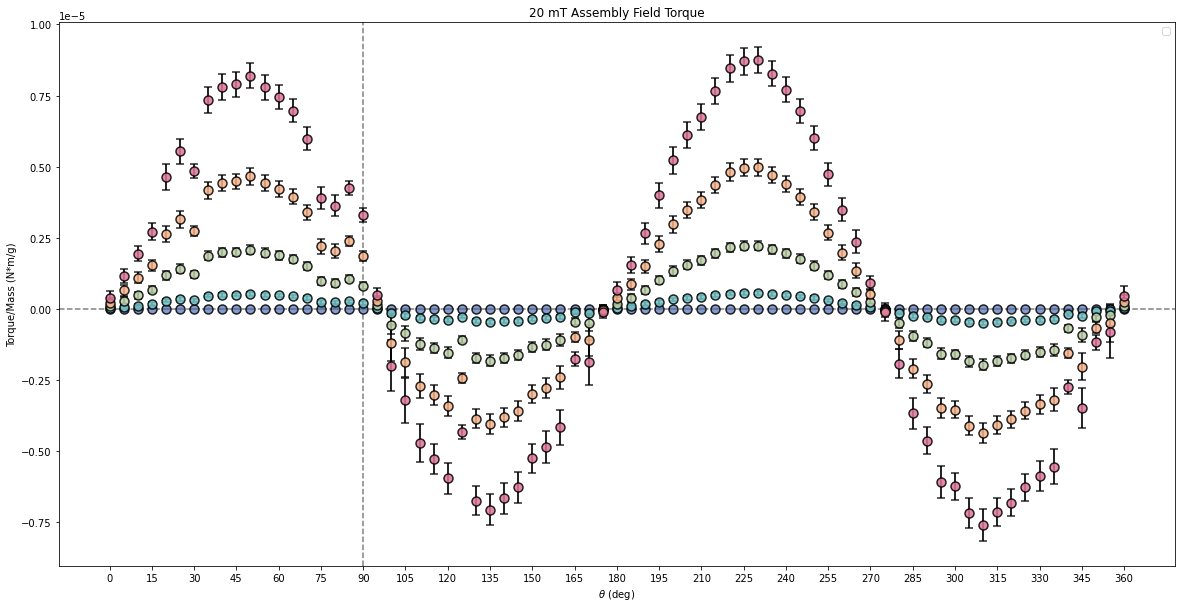

In [114]:
sample = '0.2_4mT' #Specify the sample name used to identify the directory and measurement files
cwd = os.getcwd() #Get the current working directory
wf_model_file = os.path.join(cwd, sample, 'Weak_field_model.csv') #Construct the path to the strong-field model CSV file within the current sample directory
wf_model = pd.read_csv(sf_model_file, index_col=0, header=0) #Load the model data from the CSV file into a pandas DataFrame, using the first column as the index

fields = [0, 5, 10, 15, 20] #Define the applied magnetic field values to analyze and plot
norm = Normalize(vmin=min(fields), vmax=max(fields)) #Create a normalization object that maps the field values to the range used by the colormap
theta = np.array(([key for key in x_small_wf.keys()]))[:-1] #Create an array of measurement angles from the X-direction data keys and exclude the final angle
shift = 0 #Define an angular shift to apply to the plotted data
cmap = custom_cmap #Set the colormap used to distinguish the different applied-field values
wrap = 0 #Define the number of positions used to cyclically shift the torque data
plt.figure(figsize = (20, 10)) #Create a figure with a width of 20 inches and a height of 10 inches
plt.axvline(x=90, color="k", linestyle="--", alpha=0.5, zorder=-1) #Add a vertical reference line at 90 degrees
plt.axhline(y=0, color="k", linestyle="--", alpha=0.5, zorder=-1) #Add a horizontal reference line at zero torque
for field in fields: #Loop through each applied magnetic field value
    color = cmap(norm(field)) #Assign a colormap color based on the current applied magnetic field
    T_dict, phi_dict, T_fit, theta_fit, T_err = caf.fit_torque_to_model(x_small_wf, y_small_wf, field, smoothed_fields_wf, x_err_wf, y_err_wf,
                                                                        field_min = -100, field_max = 100, plots = False, final_plots = False) #Calculate the torque, magnetic moment angle, fitted torque, fitted angle, and torque uncertainty for the current applied field using the torque model
    T_vec = np.array([T_dict[angle] for angle in theta]) #Extract the calculated torque values for each measurement angle and store them in an ordered NumPy array
    T_vec = np.roll(T_vec, -wrap)/mass_wf #Cyclically shift the torque array and normalize the torque by the sample mass
    T_err_vec = np.array([T_err[angle] for angle in theta]) #Extract the torque uncertainties for each measurement angle and store them in an ordered NumPy array
    T_err_vec = np.roll(T_err_vec, -wrap)/mass_wf #Cyclically shift the torque uncertainty array and normalize the uncertainty by the sample mass
    if field != 0: #Only load model torque data when the applied field is nonzero
        T_wf_model = sf_model.loc[:,str(field)].to_numpy() #Extract the model torque values corresponding to the current applied field from the model DataFrame
    i = 0 #Initialize an index counter for iterating through the measurement angles
    for angle in theta: #Loop through each measurement angle
        plt.errorbar(angle+shift, T_vec[i]*-1, yerr= T_err_vec[i], fmt='o', markersize=9, markerfacecolor=color, markeredgecolor='black',
                    markeredgewidth=1.5, ecolor = 'black', elinewidth=2, capsize=4, capthick=2, alpha=0.85, zorder=2) #Plot the normalized torque at the current angle with its uncertainty as a vertical error bar
        plt.plot() #Create an empty plot command
        i += 1 #Increment the index to move to the next measurement angle

plt.legend(loc = 'best') #Display a legend using the location that best avoids overlapping the plotted data
plt.xlabel(r'$\theta$ (deg)') #Label the x-axis with the sample measurement angle in degrees
plt.ylabel('Torque/Mass (N*m/g)') #Label the y-axis with the torque normalized by sample mass
plt.title('20 mT Assembly Field Torque') #Set the plot title to describe the assembly-field condition used for the sample
plt.xticks(np.linspace(0,360,25)) #Set the x-axis tick marks to 25 evenly spaced positions between 0 and 360 degrees
plt.show() #Display the completed torque plot

### Calculate Max Torque as a Function

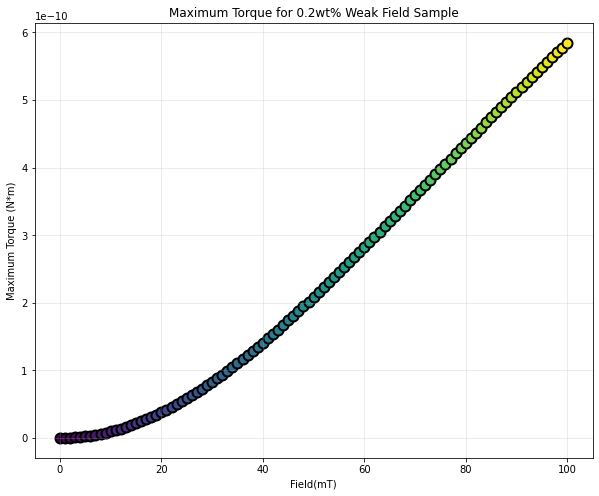

In [115]:
fields = np.linspace(0,100,101)
T_max_dict_wf = caf.plot_max_Torque(x_small_wf, y_small_wf, fields, smoothed_fields_wf, x_err_wf,
                                    y_err_wf, field_min = -100, field_max = 100, torque_plots = True, title = 'Maximum Torque for 0.2wt% Weak Field Sample')

## 0.1 wt% 20mT Sample Magnetometry Data

### Load in data for the measurements taken from 0˚–180˚ and correct diamagnetic signal

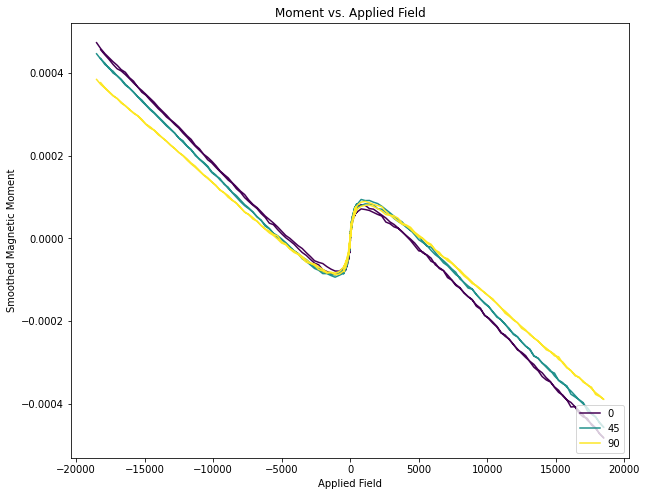

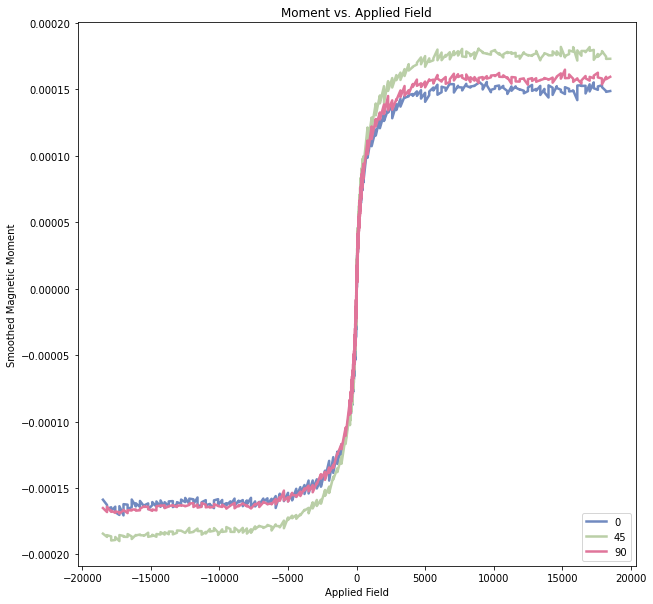

In [116]:
sample = '0.1_20mT' #Specify the sample name used to identify the directory and measurement files
angles = [0, 45, 90] #Define the measurement angles to be loaded and analyzed
x_data_1, y_data_1, _, applied_field = caf.load_x_y_data(sample, angles, str(angles[-1])) #Load the X-direction data, Y-direction data, unused processed moment data, and applied-field data for the specified sample and angles

x_data_1 = {key:x_data_1[key] for key in angles} #Rebuild the X-direction data dictionary using only the specified measurement angles
caf.plot_hysteresis(x_data_1, applied_field) #Plot the X-direction magnetic moment data as a function of applied magnetic field
diamag, corrected_data_1 = caf.correct_curves(x_data_1, applied_field, 10000, plot = False) #Correct the X-direction curves for the diamagnetic contribution using a correction field value of 10000 without displaying the correction plot
sorted_arr = np.argsort(applied_field) #Determine the indices that sort the applied-field values from smallest to largest
sorted_field = applied_field[sorted_arr] #Sort the applied-field array using the calculated sorting indices
sorted_data_1 = {key: corrected_data_1[key][sorted_arr] for key in corrected_data_1.keys()} #Sort the corrected magnetic moment data for every measurement angle using the same applied-field ordering
caf.plot_hysteresis3(sorted_data_1, sorted_field, lower_bound=None, upper_bound=None, cmap = custom_cmap) #Plot the sorted, diamagnetically corrected hysteresis curves using the custom colormap

### Truncate Data to region of interest

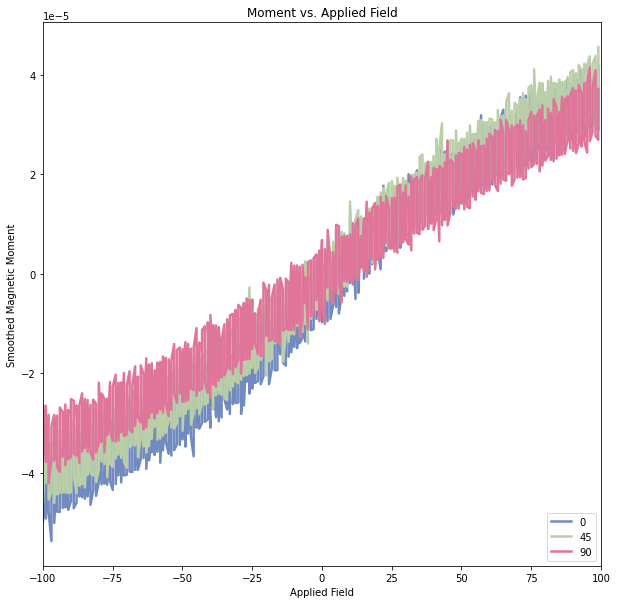

In [117]:
lower_bound = -100 #Set the lower applied-field boundary for truncating the hysteresis data
upper_bound = 100 #Set the upper applied-field boundary for truncating the hysteresis data
trunc_x, trunc_field = caf.truncate_data(sorted_data_1,sorted_field,lower_bound = lower_bound, upper_bound= upper_bound) #Filter the corrected hysteresis data and applied-field values to retain only measurements within the specified field range

angle_subset = [0, 45, 90] #Define the subset of measurement angles to include in the plot
trunc_x_s = {key:trunc_x[key] for key in angle_subset} #Create a dictionary containing only the truncated X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_x_s, trunc_field, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the truncated hysteresis curves for the selected angles using the custom colormap

### Fit the data to a langevin function. Take the error from that fitting. Adjust curves to go through (0,0)

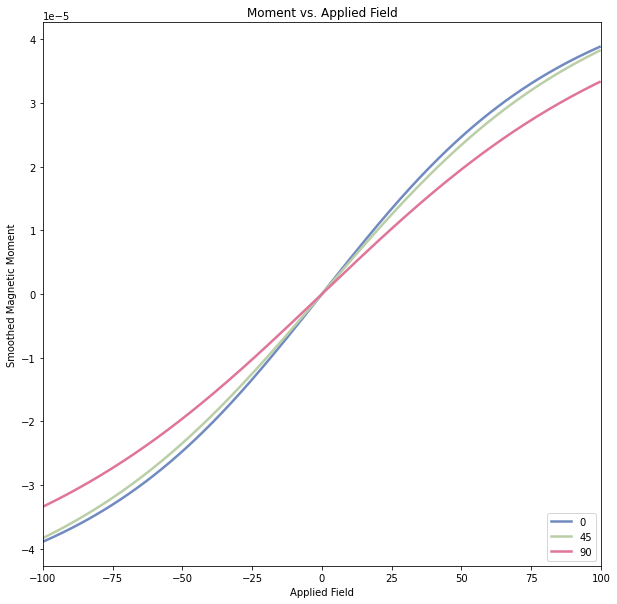

In [118]:
x_fields_1 = np.linspace(lower_bound,upper_bound,401) #Create 401 evenly spaced applied-field values between the specified lower and upper field bounds
x_params_1, x_lang_fieldvec_1 = caf.langevin_fit_with_yerr(trunc_x, trunc_field, datapoints=x_fields_1, sigma=1e-6, absolute_sigma=True, plot=False) #Fit the truncated X-direction data to a Langevin model at the specified field points and calculate the associated fitting uncertainties
x_small_1 = {key:x_params_1[key]['y_fit'] for key in x_params_1.keys()} #Extract the Langevin-fitted magnetic moment values for each measurement angle
truncated_x_lang_error_1 = {key:x_params_1[key]['y_err'] for key in x_params_1.keys()} #Extract the uncertainties associated with the Langevin-fitted magnetic moment values for each measurement angle
x_small_1 = caf.move_to_origin(x_small_1, x_fields_1) #Shift the fitted X-direction magnetic moment curves so that they are centered at the origin

angle_subset = [0, 45, 90] #Define the subset of measurement angles to include in the plot
trunc_x_s = {key:x_small_1[key] for key in angle_subset} #Create a dictionary containing only the Langevin-fitted X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_x_s, x_fields_1, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the Langevin-fitted X-direction curves for the selected measurement angles using the custom colormap

### Do all the same with y-data

Smoothing Moments between B=-100 and B=100


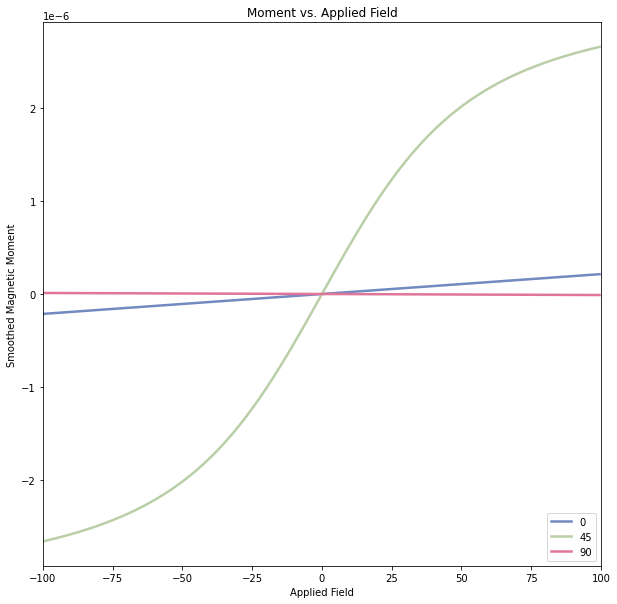

In [119]:
lower_bound = -100 #Set the lower applied-field boundary for truncating the magnetic-field data
upper_bound = 100 #Set the upper applied-field boundary for truncating the magnetic-field data
truncated_y_1, truncated_field_1 = caf.truncate_data(y_data_1,applied_field,lower_bound = lower_bound, upper_bound= upper_bound) #Filter the Y-direction data and applied-field values to retain only measurements within the specified field range
datapoints_1 = np.linspace(lower_bound,upper_bound,401) #Generate 401 evenly spaced applied-field values between the lower and upper field bounds for evaluating the Langevin fit
truncated_y_lang_1, smoothed_fields_1, truncated_y_lang_error_1 = caf.langevin_y_data360(y_data_1, applied_field, lang_datapoints = datapoints_1, #Apply the Langevin fitting procedure to the Y-direction data using the specified field values
                                                                           lower_transition=-100, higher_transition=100, y_error = 1e-6) #Set the low-field fitting region from -100 to 100 and specify the measurement uncertainty used for the fit
shifted_smoothed_y_1 = caf.move_to_origin(truncated_y_lang_1, smoothed_fields_1) #Shift the Y-direction Langevin-fitted curves so that their values are centered at the origin
angle_subset = [0, 45, 90] #Define the subset of measurement angles to include in the plot
trunc_y_s = {key:shifted_smoothed_y_1[key] for key in angle_subset} #Create a dictionary containing only the Langevin-fitted X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_y_s, smoothed_fields_1, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the Langevin-fitted X-direction curves for the selected measurement angles using the custom colormap

### Extract the X- and Y- moment values for an applied field of 10mT

X-Moment


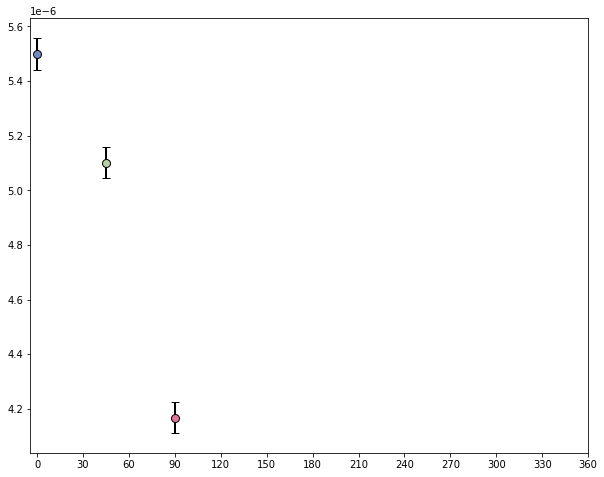

Y-Moment


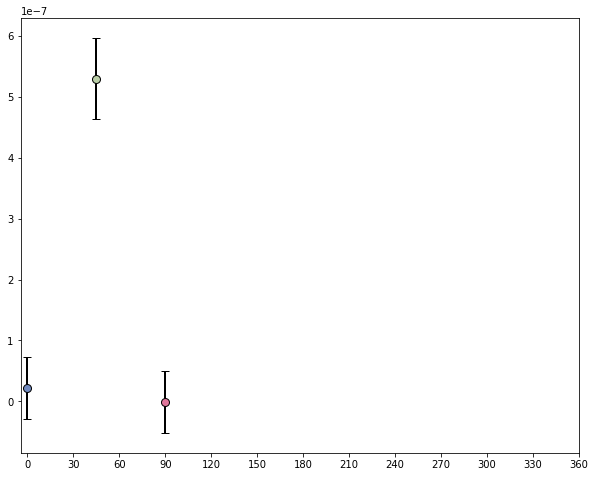

In [120]:
field = 10 #Set the applied magnetic field value at which the magnetic moment will be evaluated
mask = np.ones_like(smoothed_fields_1, dtype=bool) #Create a boolean mask initially set to True for every smoothed-field data point
mask &= smoothed_fields_1 >= -100 #Keep only data points with applied fields greater than or equal to -100
mask &= smoothed_fields_1 <= 100 #Keep only data points with applied fields less than or equal to 100

smoothed_field_1 = x_lang_fieldvec_1 #Store the applied-field values associated with the X-direction Langevin-fitted data
x_err_1 = truncated_x_lang_error_1 #Store the uncertainties associated with the X-direction Langevin-fitted data

shifted_smoothed_y_1 = caf.move_to_origin(truncated_y_lang_1, smoothed_fields_1) #Shift the Y-direction Langevin-fitted curves so that their values are centered at the origin
y_small_1 = {key:shifted_smoothed_y_1[key][mask] for key in shifted_smoothed_y_1.keys()} #Apply the field mask to the shifted Y-direction data for every measurement angle
y_err_1 = {key:truncated_y_lang_error_1[key][mask] for key in truncated_y_lang_error_1.keys()} #Apply the same field mask to the Y-direction fitting uncertainties for every measurement angle

print('X-Moment') #Print a label identifying the X-direction magnetic moment analysis
moment_dict_x_1,x_mom_err = caf.plot_specific_moment_err360(x_small_1, smoothed_field_1, x_err_1, field, ylabel = "X-Moment (emu)", plot = True, cmap = custom_cmap) #Extract and plot the X-direction magnetic moment and uncertainty at the specified applied field for each measurement angle
print('Y-Moment') #Print a label identifying the Y-direction magnetic moment analysis
moment_dict_y_1,y_mom_err = caf.plot_specific_moment_err360(y_small_1, smoothed_field_1, y_err_1, field, ylabel = "Y-Moment (emu)", plot = True, cmap = custom_cmap) #Extract and plot the Y-direction magnetic moment and uncertainty at the specified applied field for each measurement angle

### Determine Magnetic mass of the sample

### Use the saturation values to get the approximate magnetic mass of the sample. Use the set of measurements with more datapoints

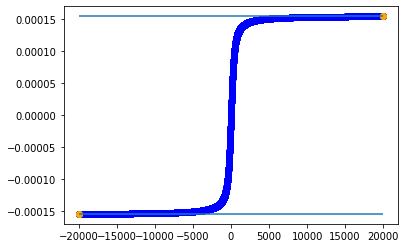

0.1wt% 20mT Field Mass:  2.5908096555850865e-06


In [121]:
angles_1 = [0, 45, 90] #Define the measurement angles to load and analyze
sample = '0.1_20mT' #Specify the sample name used to identify the measurement directory and files
x_data_1, y_data_1, data_1, applied_field_1 = caf.load_x_y_data(sample, angles_1, '90') #Load the X-direction data, Y-direction data, processed moment data, and applied-field data for the selected sample and measurement angles

full_x_1, full_field_1 = caf.truncate_data(x_data_1,applied_field_1,lower_bound = -20000, upper_bound= 20000) #Restrict the X-direction data and applied-field values to the range from -20000 to 20000
full_datapoints_1 = np.linspace(-20000,20000,40001) #Generate 40001 evenly spaced applied-field values between -20000 and 20000 for evaluating the Langevin fit
diamag, corrected_x_1 = caf.correct_curves(full_x_1, full_field_1, 5000, plot = False) #Correct the X-direction hysteresis curves for the diamagnetic contribution using a correction value of 5000 without displaying the correction plot
full_x_lang_params_1, full_x_lang_fieldvec_1 = caf.langevin_fit_with_yerr(corrected_x_1, full_field_1, datapoints=full_datapoints_1, #Fit the corrected X-direction data to a Langevin model and calculate the fitting parameters and uncertainties at the specified field values
                                                                          sigma=1e-6, absolute_sigma=True, plot=False) #Set the measurement uncertainty used for the fit and disable plotting of the Langevin fits

full_x_lang_1 = {key:full_x_lang_params_1[key]['y_fit'] for key in full_x_lang_params_1.keys()} #Extract the Langevin-fitted magnetic moment values for each measurement angle
full_x_lang_error_1 = {key:full_x_lang_params_1[key]['y_err'] for key in full_x_lang_params_1.keys()} #Extract the uncertainties associated with the Langevin-fitted magnetic moment values for each measurement angle
x = {key:x_data_1[key] for key in list(x_data_1.keys())} #Create a copy of the complete X-direction data dictionary
full_x = {key:full_x_lang_1[key] for key in list(full_x_lang_1.keys())} #Create a copy of the complete Langevin-fitted X-direction data dictionary

full_shifted_smoothed_x_1 = caf.move_to_origin(full_x_lang_1, full_x_lang_fieldvec_1) #Shift the Langevin-fitted X-direction curves so that their baseline is centered at the origin

x = {key for key in list(x_data_1.keys())[:9]} #Create a dictionary containing the first nine entries of the original X-direction data
full_smoothed_field_1 = full_x_lang_fieldvec_1 #Store the applied-field values associated with the full Langevin-fitted X-direction data
av_satval_1, mass_1 = caf.saturation_and_mass(full_shifted_smoothed_x_1, plot = True, applied_field=full_x_lang_fieldvec_1) #Calculate the average saturation magnetic moment and estimate the magnetic mass while displaying the saturation analysis plot
print('0.1wt% 20mT Field Mass: ', mass_1) #Print the estimated magnetic mass for the 0.2 wt% sample fabricated under the strong-field condition

### Calculate max torque as a function of applied field

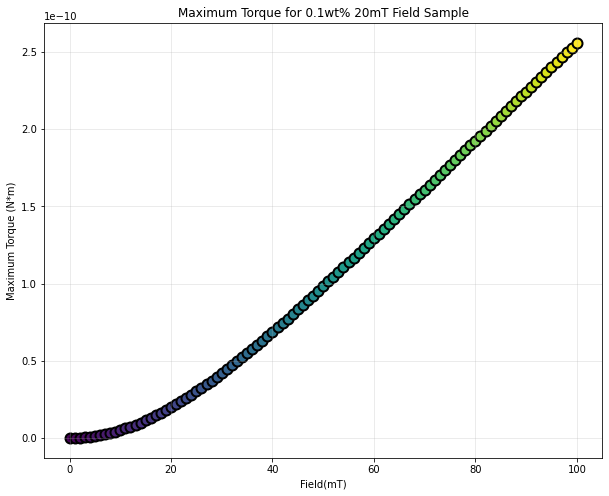

In [122]:
fields = np.linspace(0,100,101)
T_max_dict_1 = caf.plot_max_Torque(x_small_1, y_small_1, fields, smoothed_fields_1, x_err_1,
                                    y_err_1, field_min = -100, field_max = 100, torque_plots = True, title = 'Maximum Torque for 0.1wt% 20mT Field Sample')

## 0.3wt% 20mT Sample Magnetometry Data

### Load in data for the measurements taken from 0˚–180˚ and correct diamagnetic signal

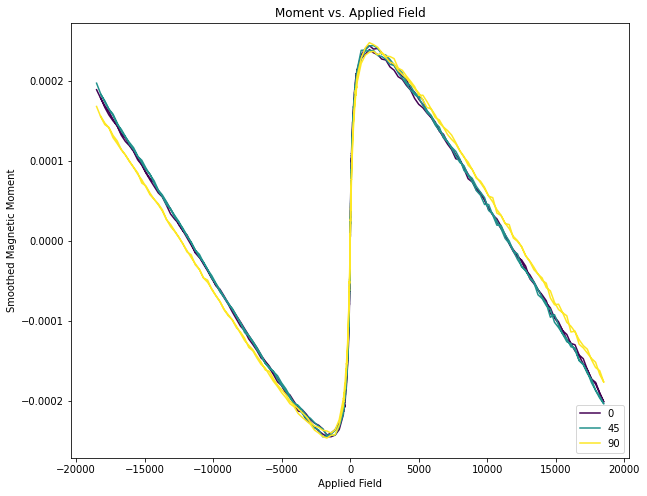

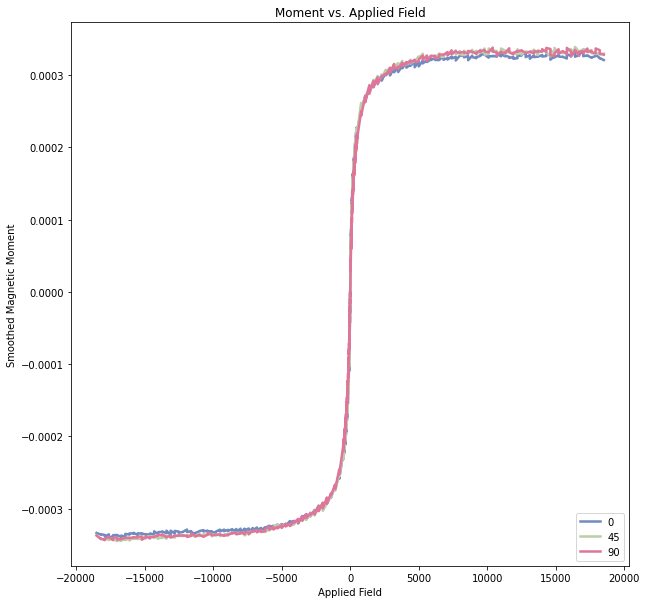

In [123]:
sample = '0.3_20mT' #Specify the sample name used to identify the directory and measurement files
angles = [0, 45, 90] #Define the measurement angles to be loaded and analyzed
x_data_3, y_data_3, _, applied_field = caf.load_x_y_data(sample, angles, str(angles[-1])) #Load the X-direction data, Y-direction data, unused processed moment data, and applied-field data for the specified sample and angles

x_data_3 = {key:x_data_3[key] for key in angles} #Rebuild the X-direction data dictionary using only the specified measurement angles
caf.plot_hysteresis(x_data_3, applied_field) #Plot the X-direction magnetic moment data as a function of applied magnetic field
diamag, corrected_data_3 = caf.correct_curves(x_data_3, applied_field, 10000, plot = False) #Correct the X-direction curves for the diamagnetic contribution using a correction field value of 10000 without displaying the correction plot
sorted_arr = np.argsort(applied_field) #Determine the indices that sort the applied-field values from smallest to largest
sorted_field = applied_field[sorted_arr] #Sort the applied-field array using the calculated sorting indices
sorted_data_3 = {key: corrected_data_3[key][sorted_arr] for key in corrected_data_3.keys()} #Sort the corrected magnetic moment data for every measurement angle using the same applied-field ordering
caf.plot_hysteresis3(sorted_data_3, sorted_field, lower_bound=None, upper_bound=None, cmap = custom_cmap) #Plot the sorted, diamagnetically corrected hysteresis curves using the custom colormap

### Truncate data to region of interest

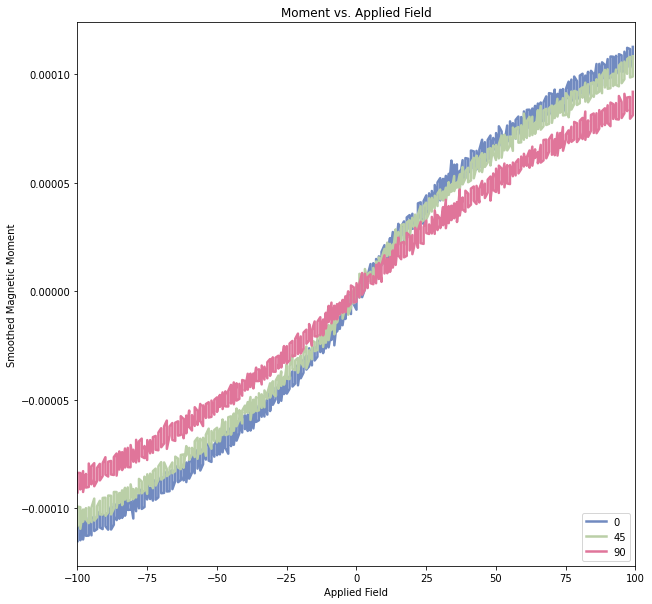

In [124]:
lower_bound = -100 #Set the lower applied-field boundary for truncating the hysteresis data
upper_bound = 100 #Set the upper applied-field boundary for truncating the hysteresis data
trunc_x, trunc_field = caf.truncate_data(sorted_data_3,sorted_field,lower_bound = lower_bound, upper_bound= upper_bound) #Filter the corrected hysteresis data and applied-field values to retain only measurements within the specified field range

angle_subset = [0, 45, 90] #Define the subset of measurement angles to include in the plot
trunc_x_s = {key:trunc_x[key] for key in angle_subset} #Create a dictionary containing only the truncated X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_x_s, trunc_field, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the truncated hysteresis curves for the selected angles using the custom colormap

### Fit the data to a langevin function. Take the error from that fitting. Adjust curves to go through (0,0)

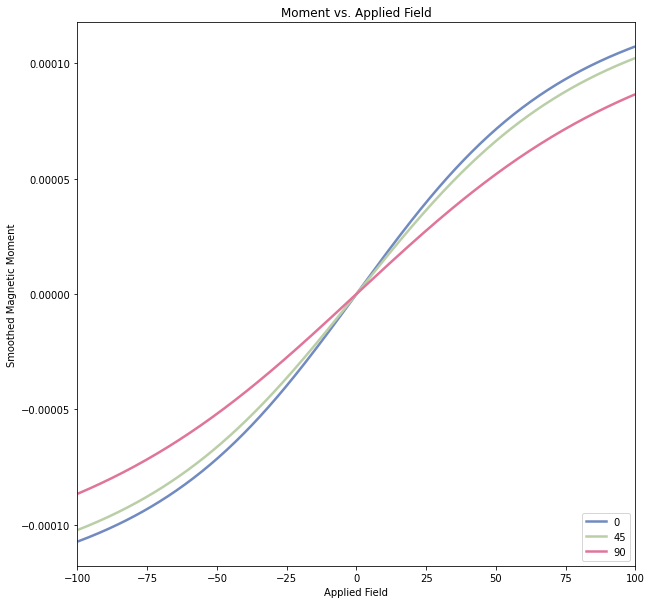

In [125]:
x_fields_3 = np.linspace(lower_bound,upper_bound,401) #Create 401 evenly spaced applied-field values between the specified lower and upper field bounds
x_params_3, x_lang_fieldvec_3 = caf.langevin_fit_with_yerr(trunc_x, trunc_field, datapoints=x_fields_3, sigma=1e-6, absolute_sigma=True, plot=False) #Fit the truncated X-direction data to a Langevin model at the specified field points and calculate the associated fitting uncertainties
x_small_3 = {key:x_params_3[key]['y_fit'] for key in x_params_3.keys()} #Extract the Langevin-fitted magnetic moment values for each measurement angle
truncated_x_lang_error_3 = {key:x_params_3[key]['y_err'] for key in x_params_3.keys()}
x_small_3 = caf.move_to_origin(x_small_3, x_fields_3) #Shift the fitted X-direction magnetic moment curves so that they are centered at the origin

angle_subset = [0, 45, 90] #Define the subset of measurement angles to include in the plot
trunc_x_s = {key:x_small_3[key] for key in angle_subset} #Create a dictionary containing only the Langevin-fitted X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_x_s, x_fields_3, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the Langevin-fitted X-direction curves for the selected measurement angles using the custom colormap

### Do all the same with the y-data

Smoothing Moments between B=-100 and B=100


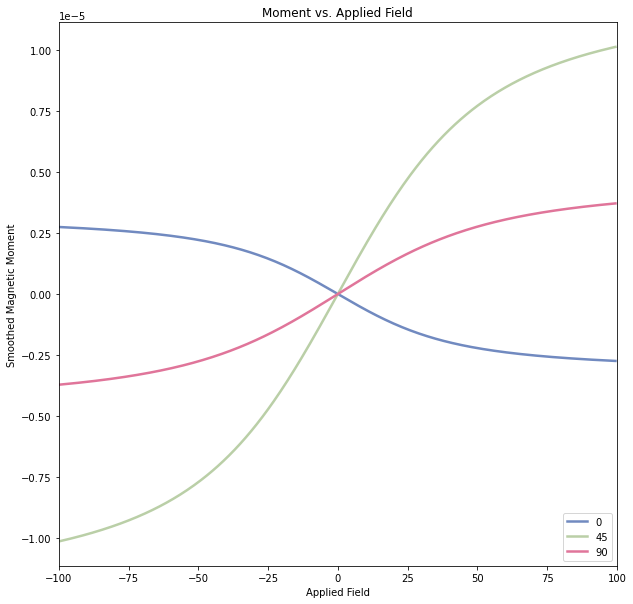

In [126]:
lower_bound = -100 #Set the lower applied-field boundary for truncating the magnetic-field data
upper_bound = 100 #Set the upper applied-field boundary for truncating the magnetic-field data
truncated_y_3, truncated_field_3 = caf.truncate_data(y_data_3,applied_field,lower_bound = lower_bound, upper_bound= upper_bound) #Filter the Y-direction data and applied-field values to retain only measurements within the specified field range
datapoints_3 = np.linspace(lower_bound,upper_bound,401) #Generate 401 evenly spaced applied-field values between the lower and upper field bounds for evaluating the Langevin fit
truncated_y_lang_3, smoothed_fields_3, truncated_y_lang_error_3 = caf.langevin_y_data360(y_data_3, applied_field, lang_datapoints = datapoints_3, #Apply the Langevin fitting procedure to the Y-direction data using the specified field values
                                                                           lower_transition=-100, higher_transition=100, y_error = 1e-6) #Set the low-field fitting region from -100 to 100 and specify the measurement uncertainty used for the fit
shifted_smoothed_y_3 = caf.move_to_origin(truncated_y_lang_3, smoothed_fields_3) #Shift the Y-direction Langevin-fitted curves so that their values are centered at the origin
angle_subset = [0, 45, 90] #Define the subset of measurement angles to include in the plot
trunc_y_s = {key:shifted_smoothed_y_3[key] for key in angle_subset} #Create a dictionary containing only the Langevin-fitted X-direction data for the selected measurement angles
caf.plot_hysteresis3(trunc_y_s, smoothed_fields_3, lower_bound=lower_bound, upper_bound=upper_bound, cmap = custom_cmap) #Plot the Langevin-fitted X-direction curves for the selected measurement angles using the custom colormap

### Extract x- and y- moment values for an applied field of 10mT

X-Moment


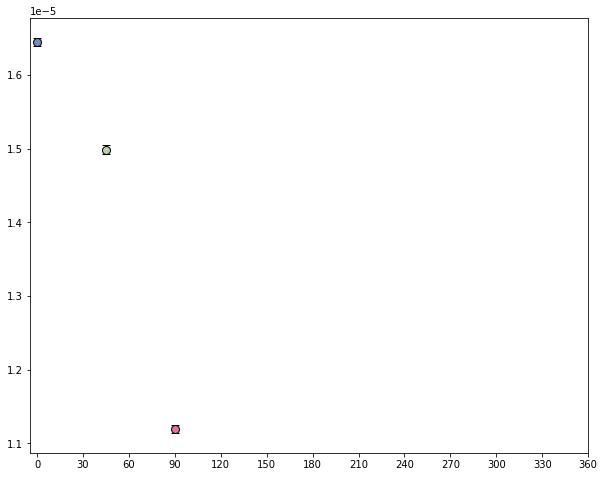

Y-Moment


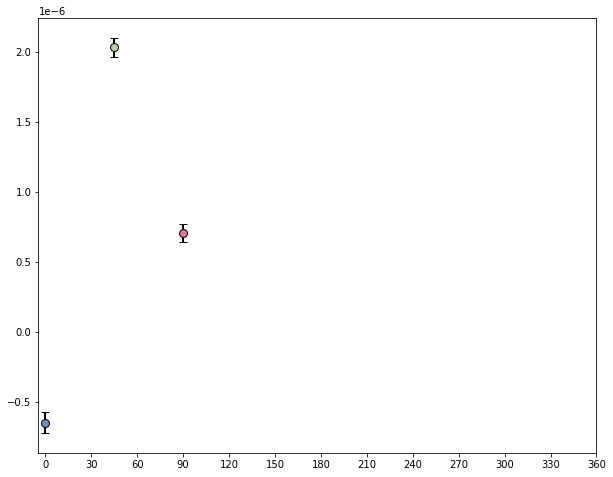

In [127]:
field = 10 #Set the applied magnetic field value at which the magnetic moment will be evaluated
mask = np.ones_like(smoothed_fields_3, dtype=bool) #Create a boolean mask initially set to True for every smoothed-field data point
mask &= smoothed_fields_3 >= -100 #Keep only data points with applied fields greater than or equal to -100
mask &= smoothed_fields_3 <= 100 #Keep only data points with applied fields less than or equal to 100

smoothed_field_3 = x_lang_fieldvec_3 #Store the applied-field values associated with the X-direction Langevin-fitted data
x_err_3 = truncated_x_lang_error_3 #Store the uncertainties associated with the X-direction Langevin-fitted data

shifted_smoothed_y_3 = caf.move_to_origin(truncated_y_lang_3, smoothed_fields_3) #Shift the Y-direction Langevin-fitted curves so that their values are centered at the origin
y_small_3 = {key:shifted_smoothed_y_3[key][mask] for key in shifted_smoothed_y_3.keys()} #Apply the field mask to the shifted Y-direction data for every measurement angle
y_err_3 = {key:truncated_y_lang_error_3[key][mask] for key in truncated_y_lang_error_3.keys()} #Apply the same field mask to the Y-direction fitting uncertainties for every measurement angle

print('X-Moment') #Print a label identifying the X-direction magnetic moment analysis
moment_dict_x_3,x_mom_err = caf.plot_specific_moment_err360(x_small_3, smoothed_field_3, x_err_3, field, ylabel = "X-Moment (emu)", plot = True, cmap = custom_cmap) #Extract and plot the X-direction magnetic moment and uncertainty at the specified applied field for each measurement angle
print('Y-Moment') #Print a label identifying the Y-direction magnetic moment analysis
moment_dict_y_3,y_mom_err = caf.plot_specific_moment_err360(y_small_3, smoothed_field_3, y_err_3, field, ylabel = "Y-Moment (emu)", plot = True, cmap = custom_cmap) #Extract and plot the Y-direction magnetic moment and uncertainty at the specified applied field for each measurement angle

### Determine magnetic mass of the sample

### Use the saturation values to get the approximate magnetic mass of the sample. Use the set of measurements with more datapoints

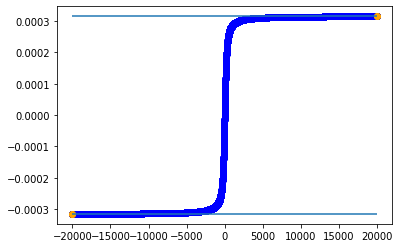

0.3wt% 20mT Field Mass:  5.091573216071964e-06


In [128]:
angles_3 = [0, 45, 90] #Define the measurement angles to load and analyze
sample = '0.3_20mT' #Specify the sample name used to identify the measurement directory and files
x_data_3, y_data_3, data_3, applied_field_3 = caf.load_x_y_data(sample, angles_3, '90') #Load the X-direction data, Y-direction data, processed moment data, and applied-field data for the selected sample and measurement angles

full_x_3, full_field_3 = caf.truncate_data(x_data_3,applied_field_3,lower_bound = -20000, upper_bound= 20000) #Restrict the X-direction data and applied-field values to the range from -20000 to 20000
full_datapoints_3 = np.linspace(-20000,20000,40001) #Generate 40001 evenly spaced applied-field values between -20000 and 20000 for evaluating the Langevin fit
diamag, corrected_x_3 = caf.correct_curves(full_x_3, full_field_3, 5000, plot = False) #Correct the X-direction hysteresis curves for the diamagnetic contribution using a correction value of 5000 without displaying the correction plot
full_x_lang_params_3, full_x_lang_fieldvec_3 = caf.langevin_fit_with_yerr(corrected_x_3, full_field_3, datapoints=full_datapoints_3, #Fit the corrected X-direction data to a Langevin model and calculate the fitting parameters and uncertainties at the specified field values
                                                                          sigma=1e-6, absolute_sigma=True, plot=False) #Set the measurement uncertainty used for the fit and disable plotting of the Langevin fits

full_x_lang_3 = {key:full_x_lang_params_3[key]['y_fit'] for key in full_x_lang_params_3.keys()} #Extract the Langevin-fitted magnetic moment values for each measurement angle
full_x_lang_error_3 = {key:full_x_lang_params_3[key]['y_err'] for key in full_x_lang_params_3.keys()} #Extract the uncertainties associated with the Langevin-fitted magnetic moment values for each measurement angle
x = {key:x_data_3[key] for key in list(x_data_3.keys())} #Create a copy of the complete X-direction data dictionary
full_x = {key:full_x_lang_3[key] for key in list(full_x_lang_3.keys())} #Create a copy of the complete Langevin-fitted X-direction data dictionary

full_shifted_smoothed_x_3 = caf.move_to_origin(full_x_lang_3, full_x_lang_fieldvec_3) #Shift the Langevin-fitted X-direction curves so that their baseline is centered at the origin

x = {key for key in list(x_data_3.keys())[:9]} #Create a dictionary containing the first nine entries of the original X-direction data
full_smoothed_field_3 = full_x_lang_fieldvec_3 #Store the applied-field values associated with the full Langevin-fitted X-direction data
av_satval_3, mass_3 = caf.saturation_and_mass(full_shifted_smoothed_x_3, plot = True, applied_field=full_x_lang_fieldvec_3) #Calculate the average saturation magnetic moment and estimate the magnetic mass while displaying the saturation analysis plot
print('0.3wt% 20mT Field Mass: ', mass_3) #Print the estimated magnetic mass for the 0.2 wt% sample fabricated under the strong-field condition

### Calculate Max Torque as a function of applied field

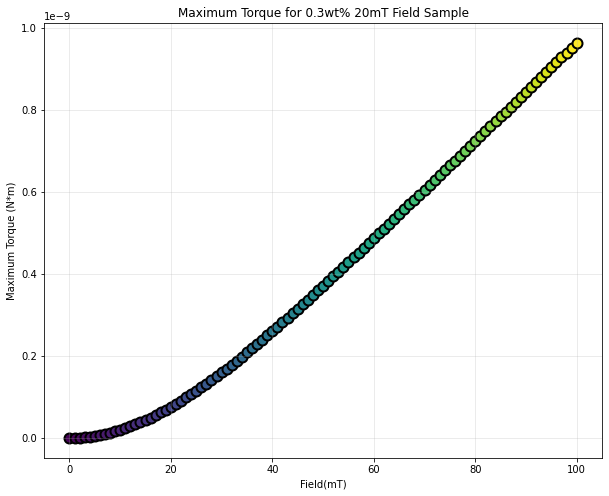

In [129]:
fields = np.linspace(0,100,101)
T_max_dict_3 = caf.plot_max_Torque(x_small_3, y_small_3, fields, smoothed_fields_3, x_err_3,
                                    y_err_3, field_min = -100, field_max = 100, torque_plots = True, title = 'Maximum Torque for 0.3wt% 20mT Field Sample')

# Compare all max torques

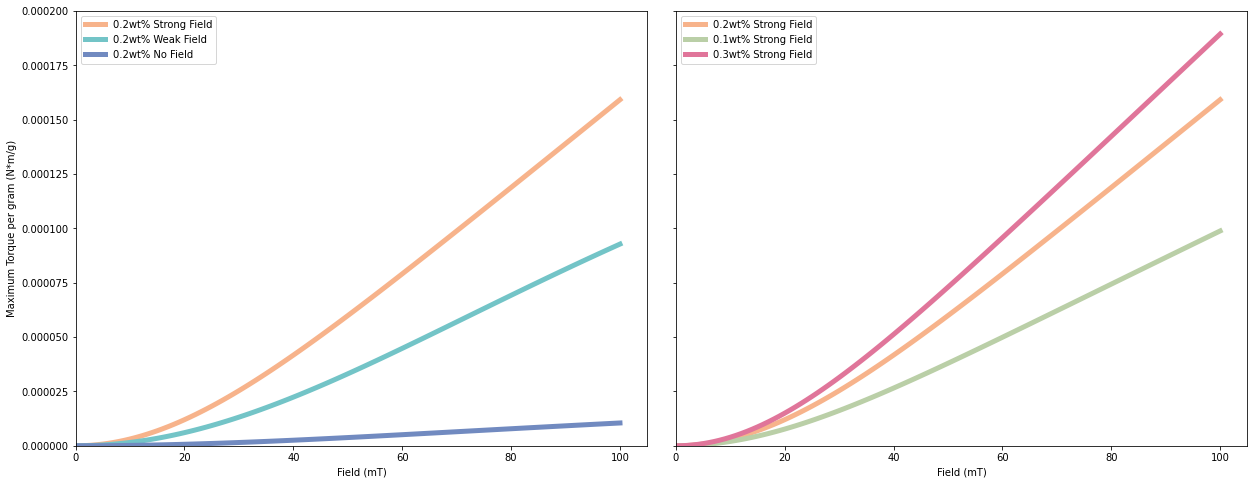

In [130]:
fields = np.linspace(0,100,101)
keys = [0, 1, 2, 3, 4]
norm = Normalize(vmin=min(keys), vmax=max(keys))
cmap = custom_cmap

fig,(ax1, ax2) = plt.subplots(1,2,figsize = (21,8), sharey = True)
ax1.plot(fields,[T_max_dict_sf[0][key]/mass_sf for key in T_max_dict_sf[0].keys()], color = cmap(norm(3)), linewidth = 5, label = '0.2wt% Strong Field')
ax1.plot(fields,[T_max_dict_wf[0][key]/mass_wf for key in T_max_dict_wf[0].keys()], color = cmap(norm(1)), linewidth = 5, label = '0.2wt% Weak Field')
ax1.plot(fields,[T_max_dict_nf[0][key]/mass_nf for key in T_max_dict_nf[0].keys()], color = cmap(norm(0)), linewidth = 5, label = '0.2wt% No Field')
ax1.set_xlim([0,None])
ax1.set_ylim([0,0.00020])

ax2.plot(fields,[T_max_dict_sf[0][key]/mass_sf for key in T_max_dict_sf[0].keys()], color = cmap(norm(3)), linewidth = 5, label = '0.2wt% Strong Field')
ax2.plot(fields,[T_max_dict_1[0][key]/mass_1 for key in T_max_dict_1[0].keys()], color = cmap(norm(2)), linewidth = 5, label = '0.1wt% Strong Field')
ax2.plot(fields,[T_max_dict_3[0][key]/mass_3 for key in T_max_dict_3[0].keys()], color = cmap(norm(4)), linewidth = 5, label = '0.3wt% Strong Field')
ax2.set_xlim([0,None])

fig.subplots_adjust(wspace=0.05)
ax1.legend(loc = 'upper left')
ax2.legend(loc = 'upper left')
ax1.set_xlabel('Field (mT)')
ax2.set_xlabel('Field (mT)')
ax1.set_ylabel('Maximum Torque per gram (N*m/g)')
plt.show()

# Compare Torques from same wt loading and include model

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


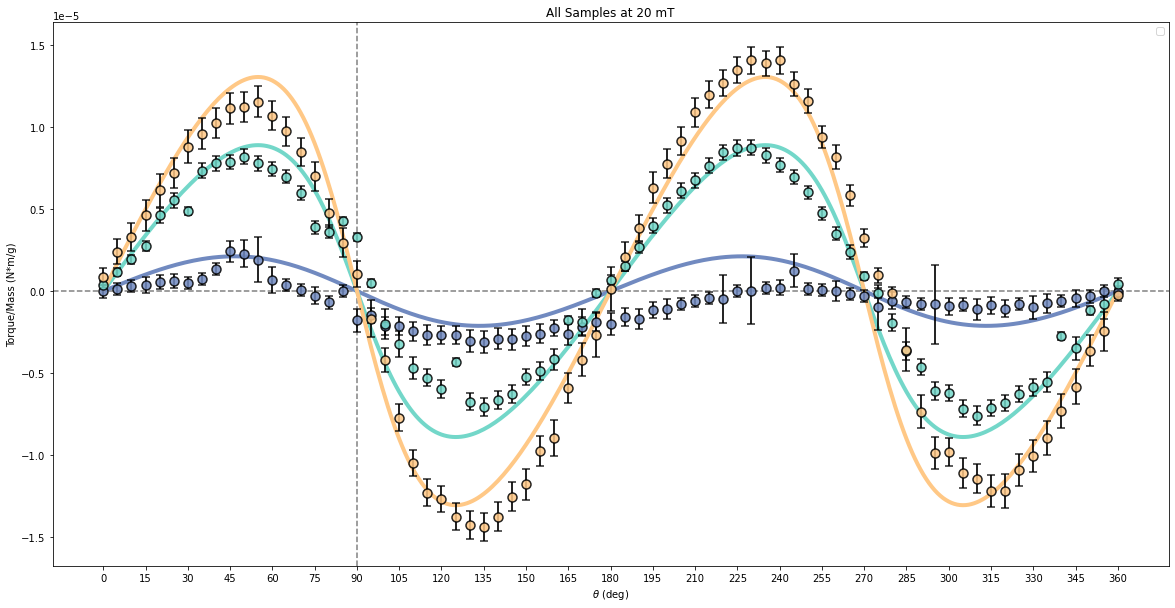

In [131]:
field = 20
cmap = custom_cmap
theta = np.linspace(0, 360, 73)
#all_thetas = np.linspace(0,360,361)
samples = ['sf', 'wf', 'nf']
shifts = [0, 0, 0]
wrap_index = [9, 0, -2]
norm = Normalize(vmin=0, vmax=len(samples))
plt.figure(figsize = (20, 10))
plt.axvline(x=90, color="k", linestyle="--", alpha=0.5, zorder=-1)
plt.axhline(y=0, color="k", linestyle="--", alpha=0.5, zorder=-1)
for sample in range(len(samples)):
    color = cmap(norm(sample))
    if sample == 2:
        T_dict_sf, phi_dict_sf, T_fit_sf, theta_fit_sf, T_err_sf = caf.fit_torque_to_model(x_small_sf, y_small_sf, field, smoothed_fields_sf, x_err_sf, y_err_sf,
                                                                                           field_min = -100, field_max = 100, plots = False, final_plots = False)
        T_vec_sf = np.array([T_dict_sf[angle] for angle in theta])
        T_vec_sf = np.roll(T_vec_sf, -wrap_index[sample])/mass_sf
        T_err_vec_sf = np.array([T_err_sf[angle] for angle in theta])
        T_err_vec_sf = np.roll(T_err_vec_sf, -wrap_index[sample])/mass_sf
        i = 0
        T_sf_model = sf_model.loc[:,str(field)].to_numpy()
        plt.plot(np.linspace(0,360,361), T_sf_model/mass_sf, linewidth = 4, color = color, zorder = 1)
        for angle in theta:
            plt.errorbar(angle+shifts[0], T_vec_sf[i]*-1, yerr= T_err_vec_sf[i], fmt='o', markersize=9, markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=1.5, ecolor = 'black', elinewidth=2, capsize=4, capthick=2, alpha=0.85, zorder=2)
            i += 1
    if sample == 1:
        T_dict_wf, phi_dict_wf, T_fit_wf, theta_fit_wf, T_err_wf = caf.fit_torque_to_model(x_small_wf, y_small_wf, field, smoothed_fields_wf, x_err_wf, y_err_wf,
                                                                                           field_min = -100, field_max = 100, plots = False, final_plots = False)
        T_vec_wf = np.array([T_dict_wf[angle] for angle in theta])
        T_vec_wf = np.roll(T_vec_wf, -wrap_index[sample])/mass_wf
        T_err_vec_wf = np.array([T_err_wf[angle] for angle in theta])
        T_err_vec_wf = np.roll(T_err_vec_wf, -wrap_index[sample])/mass_wf
        T_wf_model = wf_model.loc[:,str(field)].to_numpy()
        plt.plot(np.linspace(0,360,361), T_wf_model/mass_wf, linewidth = 4, color = color, zorder = 1)
        i = 0
        for angle in theta:
            # plt.errorbar(angle+shifts[0], T_vec, yerr= T_err_vec, fmt='o', markersize=9, markerfacecolor=color, markeredgecolor='black',
            #             markeredgewidth=1.5, ecolor = 'black', elinewidth=2, capsize=4, capthick=2, alpha=0.85, zorder=2
            plt.errorbar(angle+shifts[0], T_vec_wf[i]*-1, yerr= T_err_vec_wf[i], fmt='o', markersize=9, markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=1.5, ecolor = 'black', elinewidth=2, capsize=4, capthick=2, alpha=0.85, zorder=2)
            i += 1
    if sample == 0:
        T_dict_nf, phi_dict_nf, T_fit_nf, theta_fit_nf, T_err_nf = caf.fit_torque_to_model(x_small_nf, y_small_nf, field, smoothed_fields_nf, x_err_nf, y_err_nf,
                                                                                           field_min = -100, field_max = 100, plots = False, final_plots = False)
        T_vec_nf = np.array([T_dict_nf[angle] for angle in theta])
        T_vec_nf = np.roll(T_vec_nf, -wrap_index[sample])/mass_nf
        T_err_vec_nf = np.array([T_err_nf[angle] for angle in theta])
        T_err_vec_nf = np.roll(T_err_vec_nf, -wrap_index[sample])/mass_nf
        T_nf_model = nf_model.loc[:,str(field)].to_numpy()
        plt.plot(np.linspace(0,360,361), T_nf_model/mass_nf, linewidth = 4, color = color, zorder = 1)
        i = 0
        for angle in theta:
            plt.errorbar(angle+shifts[0], T_vec_nf[i], yerr= T_err_vec_nf[i], fmt='o', markersize=9, markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=1.5, ecolor = 'black', elinewidth=2, capsize=4, capthick=2, alpha=0.85, zorder=2)
            i += 1

plt.legend(loc = 'best')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel('Torque/Mass (N*m/g)')
plt.title('All Samples at 20 mT')
plt.xticks(np.linspace(0,360,25))
plt.show()